# EV-GNN Integrated Architecture-Attribution Analysis
## Baseline, Full Hierarchy, and Charger-Level Allocation Removal in Formal75K PublicPST

### Research question

The earlier Formal75K study established that explicitly factorising the TD3 EV-GNN decision through infrastructure levels can change both control performance and the way the policy uses the continuous EV action range. The remaining attribution question is more specific:

> **Which part of the hierarchy is necessary for the observed behavioural change?**

This notebook therefore connects two controlled comparisons:

1. **TD3 EV-GNN Baseline vs Full Hierarchical TD3 EV-GNN** — establishes what changes when infrastructure-aligned decision formation is introduced.
2. **Full Hierarchy vs Charger-Level Allocation Removed** — tests whether the charger-level allocation stage is necessary for those changes.

The final analysis uses four Formal PublicPST scenarios (25CP, 100CP, 500CP, 1000CP), ten independently trained seeds per architecture and scenario, 75,000 environment steps, scheduled deterministic evaluation every 5,000 steps, and an independent 30-episode evaluation of each selected `model.best` policy.

# PublicPST operating problem

Public Power Setpoint Tracking is an **aggregate coordination problem**. At every control interval, the charging point operator (CPO) receives a requested fleet-level power target and must coordinate many connected EVs so that realised charging power follows that request.

The physical system is not flat:

```text
CPO / fleet-level request
          |
          v
     Transformers
          |
          v
       Chargers
          |
          v
          EVs
```

The policy therefore has two related jobs:

- **control:** decide EV charging actions that track the requested aggregate power;
- **coordination:** decide how those actions should be organised across the infrastructure that connects the EVs.

A graph neural network can encode the same physical topology for all architectures while the final decision is still formed differently. That distinction is the focus of this analysis.

## Figure 1 — Three decision structures compared in the architecture-attribution study

```text
                         SAME GRAPH-STRUCTURED PUBLICPST STATE
                                        |
                  +---------------------+---------------------+
                  |                                           |
                  |                                           |
          TD3 EV-GNN BASELINE                        HIERARCHICAL FAMILY
                  |                                           |
                  v                              +------------+------------+
          graph representation                    |                         |
                  |                               v                         v
                  v                       FULL HIERARCHY          CHARGER LEVEL REMOVED
        direct EV-level action                    |                         |
                                                  v                         v
                                           transformer allocation     transformer allocation
                                                  |                         |
                                                  v                         v
                                            charger allocation       direct EV-level decision
                                                  |                         |
                                                  v                         v
                                               EV gate                  EV action
                                                  |
                                                  v
                                               EV action
```

All three policies retain graph-structured state information and the same charging-only EV action domain. The intervention is therefore **how the final EV decision is factorised**, not whether topology is available to the actor.

### Formal action formation

For the **TD3 EV-GNN Baseline**, the graph encoder produces node representations and the EV-node output is mapped directly into the charging-only range:

\[
a_i^{\text{base}}
=
\frac{a_{\max}}{2}
\left[\tanh(z_i)+1\right].
\]

For the **Full Hierarchical TD3 EV-GNN**, the actor first forms a graph-level scale \(B_G\), then allocates decision authority through transformer and charger levels before applying an EV-specific gate:

\[
a_i^{\text{full}}
=
\operatorname{clip}
\left(
B_G\,
w_T(i)\,
w_{C|T}(i)\,
g_i,
0,
a_{\max}
\right).
\]

The **Charger-Level Allocation Removed** architecture retains transformer-level hierarchical decision formation but removes the explicit charger allocation stage:

\[
a_i^{\text{removal}}
=
\operatorname{clip}
\left(
B_G\,
w_T(i)\,
u_i,
0,
a_{\max}
\right),
\]

where \(u_i\) is the EV-level decision term formed after the transformer-level allocation.

### Minimal code-level comparison

```python
# TD3 EV-GNN Baseline
node_embeddings = gnn(graph_state)
raw_logits = action_head(node_embeddings)
ev_action = 0.5 * max_action * (torch.tanh(raw_logits) + 1.0)

# Full Hierarchical TD3 EV-GNN
node_embeddings = gnn(graph_state)
transformer_weight = graph_softmax(transformer_scores)
charger_weight = grouped_softmax(charger_scores, parent_transformer)
ev_gate = torch.sigmoid(ev_gate_logits)

ev_action = (
    active_ev_count
    * transformer_weight
    * charger_weight
    * ev_gate
).clamp(0.0, max_action)

# Charger-Level Allocation Removed
node_embeddings = gnn(graph_state)
transformer_weight = graph_softmax(transformer_scores)
ev_term = direct_ev_decision(node_embeddings, transformer_context)

ev_action = (
    active_ev_count
    * transformer_weight
    * ev_term
).clamp(0.0, max_action)
```

These fragments are deliberately minimal. They are included to make the three **decision-forming pathways** concrete rather than to reproduce the full implementation.

### Reading the three pathways in plain language

#### Baseline: direct EV-level decision formation

The baseline uses the graph to understand each EV in context, but after that representation has been formed it turns the EV-node output directly into a charging command. There is no explicit intermediate allocation that first divides the decision across transformer or charger branches.

#### Full hierarchy: step-by-step infrastructure-factorised decision formation

The full hierarchy inserts two explicit infrastructure decisions before the final EV action. It first divides graph-level decision authority across transformers, then divides each transformer share across chargers, and finally applies the EV-specific gate.

#### Charger level removed: transformer hierarchy without the intermediate charger allocation

The reduced hierarchy does **not** return to the baseline. It still makes an explicit transformer-level allocation before the final EV decision. What changes is the removal of the intermediate charger-allocation stage.

This distinction is what makes the ablation useful: if an effect remains after charger allocation is removed, that effect cannot require the explicit charger-level factorisation itself.

In [1]:
# Numerical illustration of action formation only; these values are not experimental results.
import numpy as np

max_action = 1.0
active_evs = 4

baseline_logit = 0.40
baseline_action = 0.5 * max_action * (np.tanh(baseline_logit) + 1.0)

transformer_weight = 0.30
charger_weight = 0.50
ev_gate = 0.60
full_action = np.clip(
    active_evs * transformer_weight * charger_weight * ev_gate,
    0.0,
    max_action,
)

direct_ev_term = 0.30
removal_action = np.clip(
    active_evs * transformer_weight * direct_ev_term,
    0.0,
    max_action,
)

print(f"Illustrative baseline action:        {baseline_action:.3f}")
print(f"Illustrative full-hierarchy action:  {full_action:.3f}")
print(f"Illustrative charger-removed action: {removal_action:.3f}")

Illustrative baseline action:        0.690
Illustrative full-hierarchy action:  0.360
Illustrative charger-removed action: 0.360


The toy calculation is only a mechanical illustration. It shows how the same final action range can be reached through three different structures:

```text
Baseline:
graph representation
→ direct EV-level transform

Full hierarchy:
graph representation
→ transformer share
→ charger share
→ EV gate
→ EV command

Charger level removed:
graph representation
→ transformer share
→ EV-level decision
→ EV command
```

The numbers do **not** predict which architecture should have the better reward. They only make clear what information is explicitly factorised before the EV action is produced.

# Why the two-stage Formal75K study was required

The architecture question had to be separated into two steps.

The first Formal75K comparison aligned the TD3 framework, PublicPST task, graph state, charging-only action range, training budget, training-seed labels, checkpoint-selection procedure, and final evaluation protocol. That comparison asked whether **full infrastructure-aligned decision formation** changed the controller relative to the direct-action baseline.

Once that effect was established, the charger-removal experiment asked a narrower question:

> If transformer-level hierarchical decision formation is retained, what changes when the explicit charger-level allocation is removed?

This second comparison is therefore an **architecture-attribution experiment**, not a new control task.

# Formal experimental design

The three architectures are compared under the same four Formal PublicPST configurations.

| Element | Formal setting |
|---|---|
| Scenarios | 25CP, 100CP, 500CP, 1000CP |
| Training seeds | 0–9 for every architecture and scenario |
| Training budget | 75,000 environment steps |
| Scheduled deterministic evaluation | Every 5,000 steps |
| Scheduled evaluation points | 15 per trained run |
| Final selected-policy evaluation | 30 deterministic episodes per `model.best` policy |
| Formal inferential unit | Independently trained policy / training seed |
| Primary ablation | Charger-Level Allocation Removed minus Full Hierarchy |

For final evaluation, the 30 deterministic episodes are first averaged **within each trained policy**. Architecture inference is then performed across the ten paired training-seed means.

This distinction matters: the 300 episode rows in one architecture/scenario describe within-policy evaluation variation, but they do not represent 300 independently trained policies.

## Cross-scale interpretation rule

The four scenarios are progressively larger configured systems, but they are **not a one-factor charger-count experiment**. The physical configuration also changes across scenarios, including the number of transformer branches, and the 25CP case uses a different flexibility setting from the larger scenarios.

For that reason, the notebook asks whether an architectural pattern is **robust across the four formal configurations**. It does not interpret a 25CP-to-1000CP trend as a clean causal effect of charger count alone.

## How the computational analysis is organised

The following code cells follow the same order as the research argument:

1. load the aligned Formal75K and charger-removal result tables;
2. place all three architectures onto common policy-level variables;
3. compare scheduled deterministic evaluation behaviour;
4. evaluate the selected `model.best` policies;
5. analyse paired reward effects and seed heterogeneity;
6. examine action composition, infrastructure stress, and EV service;
7. synthesise which part of the hierarchy is necessary for which effect.

The code is kept next to the result it produces so that the notebook remains readable as a computational research record rather than a detached analysis script.

In [2]:
# Analysis setup and shared figure conventions.
from pathlib import Path
import itertools
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from scipy import stats

COMPARISON_ROOT = Path("..").resolve()
INPUT_ROOT = COMPARISON_ROOT / "input_data"
EXPERIMENT_ROOT = COMPARISON_ROOT.parent

removal_eval_file = next(
    (EXPERIMENT_ROOT / "03_final_analysis_outputs").rglob(
        "transformer_ev_eval30_episode_rows.csv"
    )
)
REMOVAL_ROOT = removal_eval_file.parent

SCALE_ORDER = ["25cp", "100cp", "500cp", "1000cp"]
SCALE_LABELS = {
    "25cp": "25CP",
    "100cp": "100CP",
    "500cp": "500CP",
    "1000cp": "1000CP",
}

ARCH_ORDER = ["baseline", "full", "removal"]
ARCH_LABELS = {
    "baseline": "TD3 EV-GNN Baseline",
    "full": "Full Hierarchical TD3 EV-GNN",
    "removal": "Charger-Level Allocation Removed",
}
ARCH_SHORT = {
    "baseline": "Baseline",
    "full": "Full Hierarchy",
    "removal": "Charger Removed",
}

_algorithm_to_architecture = {
    "actiongnn_nonnegative": "baseline",
    "hierarchical": "full",
    "hierarchical_transformer_ev": "removal",
}

_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ARCH_COLOUR = {
    "baseline": _cycle[0],
    "full": _cycle[1],
    "removal": _cycle[2],
}
COMPONENT_COLOUR = {
    "Zero action": _cycle[3],
    "Interior action": _cycle[2],
    "Maximum action": _cycle[1],
}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

def compact_number(value):
    value = float(value)
    sign = "-" if value < 0 else ""
    x = abs(value)
    if x >= 1e9:
        return f"{sign}{x / 1e9:.1f}B"
    if x >= 1e6:
        return f"{sign}{x / 1e6:.1f}M"
    if x >= 1e3:
        return f"{sign}{x / 1e3:.1f}k"
    return f"{value:.2f}"

def signed_compact(value):
    value = float(value)
    if abs(value) >= 1e6:
        return f"{value / 1e6:+.2f}M"
    if abs(value) >= 1e3:
        return f"{value / 1e3:+.2f}k"
    return f"{value:+.2f}"

def compact_tick(value, _):
    return compact_number(value)

COMPACT_FORMATTER = FuncFormatter(compact_tick)

def percent_text(value, decimals=1):
    return f"{100 * float(value):.{decimals}f}%"

### Loading the aligned result tables

The next cell loads three evidence layers:

- **scheduled deterministic evaluation** — how the current policy behaved at each 5,000-step checkpoint;
- **independent selected-policy evaluation** — the 30-episode `model.best` outcome used for control and service comparisons;
- **infrastructure diagnostics** — action composition, allocation concentration, transformer overload, and related mechanism variables.

Only research-facing variables are carried forward into the common three-architecture tables.

In [3]:
formal_eval = pd.read_csv(INPUT_ROOT / "formal75k_eval30_episode_rows_all80.csv")
formal_diag = pd.read_csv(INPUT_ROOT / "formal75k_diagnostic_episode_rows_all80.csv")
formal_sched = pd.read_csv(INPUT_ROOT / "formal75k_scheduled_evaluation_rows_all80.csv")

removal_eval = pd.read_csv(REMOVAL_ROOT / "transformer_ev_eval30_episode_rows.csv")
removal_diag = pd.read_csv(REMOVAL_ROOT / "transformer_ev_diagnostic_episode_rows.csv")
removal_sched = pd.read_csv(REMOVAL_ROOT / "transformer_ev_training_curve_long.csv")
removal_matrix = pd.read_csv(REMOVAL_ROOT / "transformer_ev_training_matrix_summary.csv")

formal_eval = formal_eval.assign(
    architecture=formal_eval["algorithm"].map(_algorithm_to_architecture),
    average_satisfaction=formal_eval["average_user_satisfaction"],
    energy_delivered=formal_eval["total_energy_charged"],
    evs_served=formal_eval["total_ev_served"],
    transformer_overload=formal_eval["total_transformer_overload"],
)

removal_eval = removal_eval.assign(
    architecture="removal",
    training_seed=removal_eval["seed"].astype(int),
)

eval_columns = [
    "architecture", "algorithm", "scale", "training_seed",
    "episode_index", "episode_seed",
    "episode_reward", "tracking_error",
    "energy_tracking_error", "power_tracker_violation",
    "transformer_overload", "average_satisfaction",
    "energy_delivered", "evs_served",
]

eval_episodes = pd.concat(
    [formal_eval[eval_columns], removal_eval[eval_columns]],
    ignore_index=True,
)

policy_eval = (
    eval_episodes
    .groupby(["architecture", "algorithm", "scale", "training_seed"], observed=True)[
        [
            "episode_reward", "tracking_error",
            "energy_tracking_error", "power_tracker_violation",
            "transformer_overload", "average_satisfaction",
            "energy_delivered", "evs_served",
        ]
    ]
    .mean()
    .reset_index()
)

The diagnostic schemas use different column names because the third architecture was evaluated by the later three-architecture analysis pipeline. The next cell maps both evidence sets onto the same physical quantities.

For action composition, the notebook uses three mutually interpretable components:

- **zero action** — no charging command;
- **interior action** — positive charging below the upper action boundary;
- **maximum action** — charging at the upper boundary.

The interior fraction is therefore the positive non-zero action fraction minus the upper-bound fraction.

In [4]:
formal_diag = formal_diag.assign(
    architecture=formal_diag["algorithm"].map(_algorithm_to_architecture),
    active_max_fraction=formal_diag["global_action_fraction_at_positive_max_active"],
    active_nonzero_fraction=formal_diag["global_positive_action_fraction_active"],
    active_zero_fraction=formal_diag["global_zero_action_fraction_active"],
    transformer_hhi=formal_diag["transformer_positive_charge_action_hhi_mean"],
    transformer_gini=formal_diag["transformer_positive_charge_action_gini_mean"],
    charger_group_hhi=formal_diag["charger_positive_charge_action_hhi_mean"],
    charger_group_gini=formal_diag["charger_positive_charge_action_gini_mean"],
    transformer_overload=formal_diag["total_transformer_overload"],
    average_satisfaction=formal_diag["average_user_satisfaction"],
    energy_delivered=formal_diag["total_energy_charged"],
    evs_served=formal_diag["total_ev_served"],
)
formal_diag["active_interior_fraction"] = (
    formal_diag["active_nonzero_fraction"]
    - formal_diag["active_max_fraction"]
)

removal_diag = removal_diag.assign(
    architecture="removal",
    training_seed=removal_diag["seed"].astype(int),
    active_max_fraction=removal_diag["upper_bound_active_ev_action_fraction"],
    active_nonzero_fraction=removal_diag["active_nonzero_action_fraction"],
    transformer_hhi=removal_diag["transformer_positive_pressure_hhi"],
    transformer_gini=removal_diag["transformer_positive_pressure_gini"],
    charger_group_hhi=removal_diag["charger_positive_pressure_hhi"],
    charger_group_gini=removal_diag["charger_positive_pressure_gini"],
)
removal_diag["active_zero_fraction"] = 1.0 - removal_diag["active_nonzero_fraction"]
removal_diag["active_interior_fraction"] = (
    removal_diag["active_nonzero_fraction"]
    - removal_diag["active_max_fraction"]
)

diag_columns = [
    "architecture", "algorithm", "scale", "training_seed",
    "episode_index", "episode_seed",
    "active_zero_fraction", "active_interior_fraction",
    "active_max_fraction", "active_nonzero_fraction",
    "transformer_hhi", "transformer_gini",
    "charger_group_hhi", "charger_group_gini",
    "transformer_overload", "power_tracker_violation",
    "tracking_error", "energy_tracking_error",
    "average_satisfaction", "energy_delivered", "evs_served",
]

diagnostic_episodes = pd.concat(
    [formal_diag[diag_columns], removal_diag[diag_columns]],
    ignore_index=True,
)

policy_diag = (
    diagnostic_episodes
    .groupby(["architecture", "algorithm", "scale", "training_seed"], observed=True)[
        [
            "active_zero_fraction", "active_interior_fraction",
            "active_max_fraction", "active_nonzero_fraction",
            "transformer_hhi", "transformer_gini",
            "charger_group_hhi", "charger_group_gini",
            "transformer_overload", "power_tracker_violation",
            "tracking_error", "energy_tracking_error",
            "average_satisfaction", "energy_delivered", "evs_served",
        ]
    ]
    .mean()
    .reset_index()
)

### Placing all three architectures on one scheduled-evaluation timeline

The Formal75K baseline/full-hierarchy table and the charger-removal table both contain deterministic evaluations every 5,000 steps. The next cell standardises them into the same columns so that the learning curves can be compared without mixing in exploration-time training reward.

In [5]:
formal_scheduled = (
    formal_sched[
        ["scale", "algorithm", "training_seed", "timestep", "eval/mean_reward"]
    ]
    .rename(columns={"eval/mean_reward": "eval_mean_reward"})
    .assign(
        architecture=lambda d: d["algorithm"].map(_algorithm_to_architecture)
    )
)

removal_scheduled = (
    removal_sched[
        ["scale", "algorithm", "seed", "timestep", "eval_mean_reward"]
    ]
    .rename(columns={"seed": "training_seed"})
    .assign(architecture="removal")
)

scheduled = pd.concat(
    [formal_scheduled, removal_scheduled],
    ignore_index=True,
)

# Training and selected-checkpoint behaviour
## Figure 2 — Scheduled deterministic evaluation across the three architectures

This is the cleanest training-progress layer shared by all three architectures.

Each thin line is one independently trained seed. The thicker line is the cross-seed median at that checkpoint, and the shaded band is the interquartile range across the ten seeds.

Because exploration noise is removed for these scheduled evaluations, the curves answer a simple question:

> As training proceeds, where do the deterministic policies actually perform, and how similarly do the ten independent training runs behave?

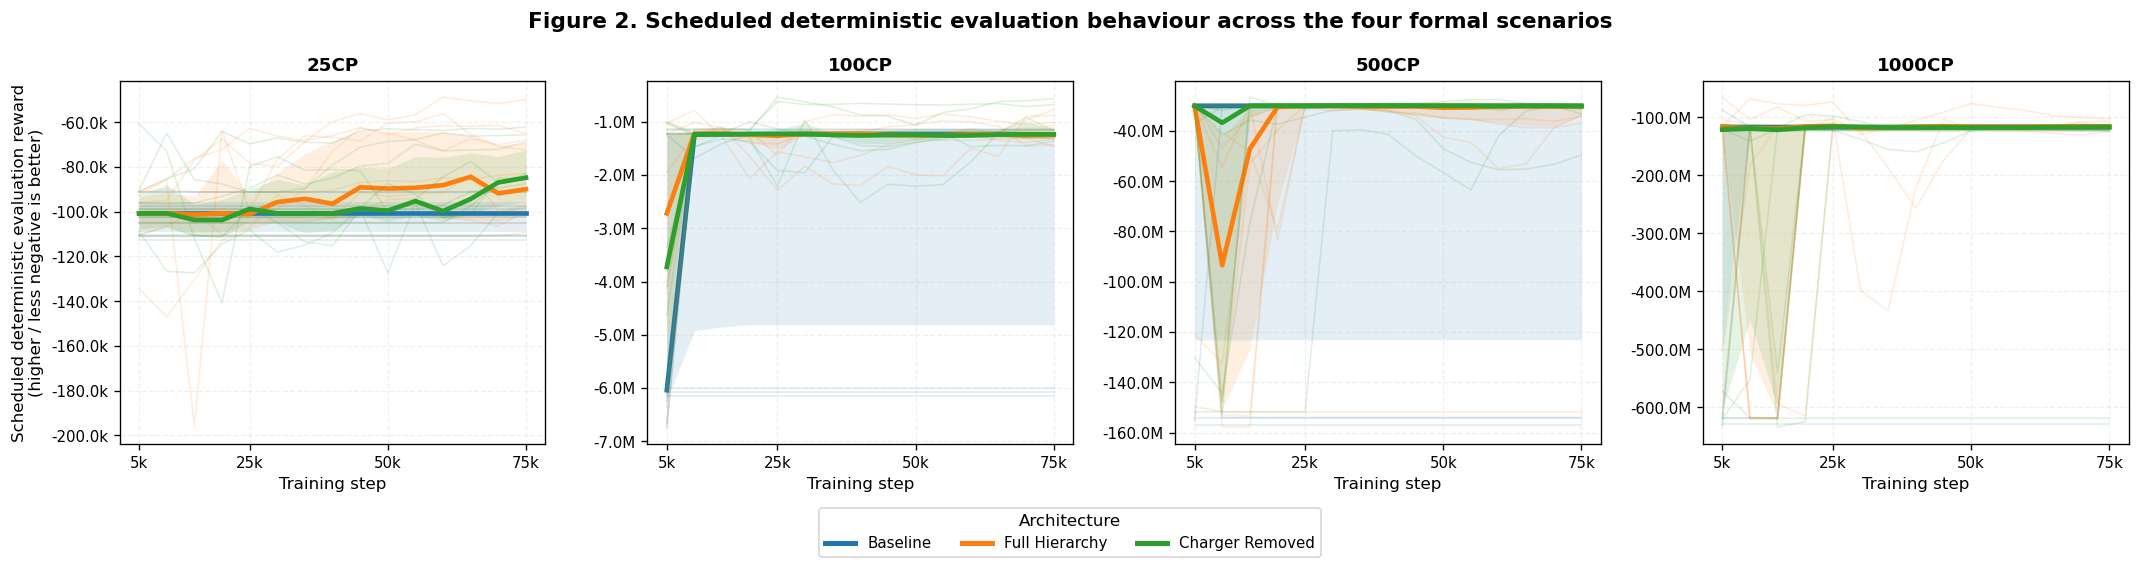

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), sharex=True)
fig.subplots_adjust(left=0.06, right=0.99, top=0.86, bottom=0.23, wspace=0.24)

for ax, scale in zip(axes, SCALE_ORDER):
    scale_data = scheduled[scheduled["scale"] == scale]

    for architecture in ARCH_ORDER:
        d = scale_data[scale_data["architecture"] == architecture]
        pivot = (
            d.pivot(index="training_seed", columns="timestep", values="eval_mean_reward")
             .sort_index()
             .sort_index(axis=1)
        )

        x = pivot.columns.to_numpy(float)
        values = pivot.to_numpy(float)

        for row in values:
            ax.plot(
                x, row,
                color=ARCH_COLOUR[architecture],
                alpha=0.14,
                linewidth=1.0,
            )

        median = np.nanmedian(values, axis=0)
        q25 = np.nanpercentile(values, 25, axis=0)
        q75 = np.nanpercentile(values, 75, axis=0)

        ax.plot(
            x, median,
            color=ARCH_COLOUR[architecture],
            linewidth=2.8,
            label=ARCH_SHORT[architecture],
        )
        ax.fill_between(
            x, q25, q75,
            color=ARCH_COLOUR[architecture],
            alpha=0.12,
            linewidth=0,
        )

    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.set_xlabel("Training step")
    ax.yaxis.set_major_formatter(COMPACT_FORMATTER)
    ax.grid(alpha=0.18, linestyle="--")
    ax.set_xticks([5000, 25000, 50000, 75000])
    ax.set_xticklabels(["5k", "25k", "50k", "75k"])

axes[0].set_ylabel("Scheduled deterministic evaluation reward\n(higher / less negative is better)")

handles = [
    Line2D([0], [0], color=ARCH_COLOUR[a], lw=3, label=ARCH_SHORT[a])
    for a in ARCH_ORDER
]
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
    title="Architecture",
)
fig.suptitle(
    "Figure 2. Scheduled deterministic evaluation behaviour across the four formal scenarios",
    fontsize=13,
    fontweight="bold",
)
plt.show()

### How to read Figure 2 in plain language

The thin lines matter because the median alone can hide difficult training runs. If most thin trajectories occupy the same reward region, independent seeds are learning similar policies. If a small number of lines fall far below the rest, the architecture has a **failure tail** even when its median remains competitive.

The figure is still a training-progress view, not the final architecture comparison. Final inference is based on the independently evaluated selected `model.best` policies later in the notebook.

## Figure 3 — When was each selected policy chosen?

The selected checkpoint is the scheduled evaluation point that produced the `model.best` policy used for final assessment.

This is best interpreted as **selected-checkpoint timing**, not as a universal convergence-speed measure. A late selected checkpoint means later scheduled evaluations eventually exceeded that seed's earlier candidates; it does not by itself prove that the architecture converges more slowly.

,Scenario,Baseline,Full Hierarchy,Charger Removed
0,25CP,5k,60k,70k
1,100CP,5k,30k,37.5k
2,500CP,5k,25k,15k
3,1000CP,5k,10k,25k


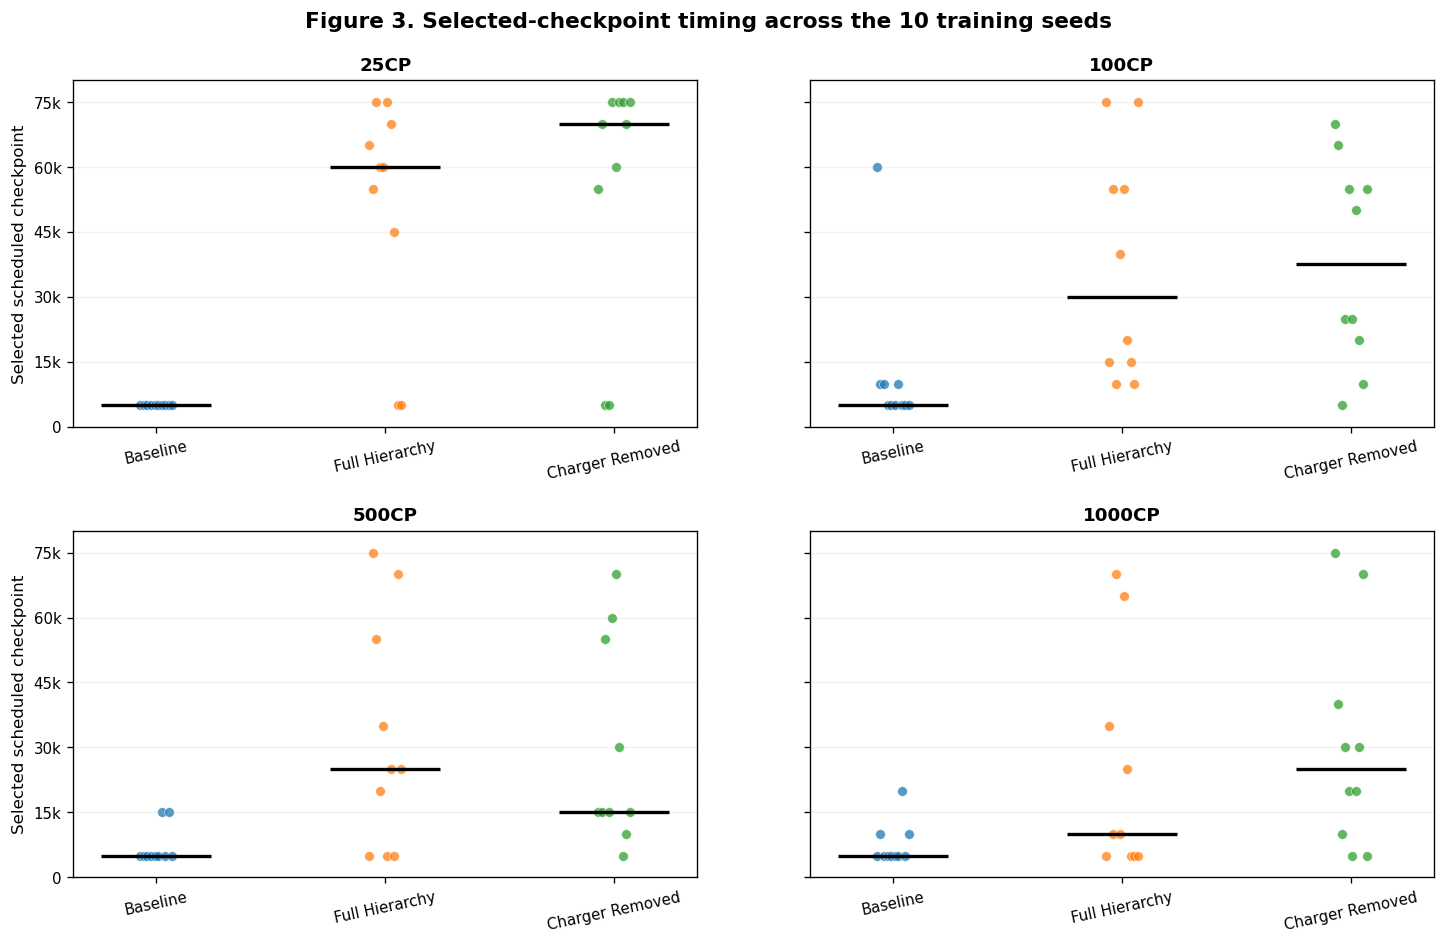

In [7]:
checkpoint_rows = []

formal_for_checkpoint = formal_scheduled.copy()
for keys, group in formal_for_checkpoint.groupby(
    ["architecture", "algorithm", "scale", "training_seed"],
    observed=True,
):
    selected = group.sort_values(
        ["eval_mean_reward", "timestep"],
        ascending=[False, True],
    ).iloc[0]
    checkpoint_rows.append({
        "architecture": keys[0],
        "algorithm": keys[1],
        "scale": keys[2],
        "training_seed": int(keys[3]),
        "selected_checkpoint_step": int(selected["timestep"]),
    })

for _, row in removal_matrix.iterrows():
    checkpoint_rows.append({
        "architecture": "removal",
        "algorithm": row["algorithm"],
        "scale": row["scale"],
        "training_seed": int(row["seed"]),
        "selected_checkpoint_step": int(row["best_checkpoint_step"]),
    })

checkpoint_frame = pd.DataFrame(checkpoint_rows)

checkpoint_summary = (
    checkpoint_frame
    .groupby(["scale", "architecture"], observed=True)["selected_checkpoint_step"]
    .median()
    .unstack("architecture")
    .reindex(SCALE_ORDER)
)

checkpoint_table = pd.DataFrame({
    "Scenario": [SCALE_LABELS[s] for s in SCALE_ORDER],
    "Baseline": [f"{checkpoint_summary.loc[s, 'baseline']/1000:g}k" for s in SCALE_ORDER],
    "Full Hierarchy": [f"{checkpoint_summary.loc[s, 'full']/1000:g}k" for s in SCALE_ORDER],
    "Charger Removed": [f"{checkpoint_summary.loc[s, 'removal']/1000:g}k" for s in SCALE_ORDER],
})
display(checkpoint_table)

fig, axes = plt.subplots(2, 2, figsize=(12.6, 8.2), sharey=True)
fig.subplots_adjust(left=0.08, right=0.98, top=0.91, bottom=0.10, hspace=0.30, wspace=0.18)

for ax, scale in zip(axes.ravel(), SCALE_ORDER):
    d = checkpoint_frame[checkpoint_frame["scale"] == scale]
    x_positions = np.arange(len(ARCH_ORDER))

    for x, architecture in zip(x_positions, ARCH_ORDER):
        values = (
            d[d["architecture"] == architecture]
            .sort_values("training_seed")["selected_checkpoint_step"]
            .to_numpy(float)
        )
        jitter = np.linspace(-0.07, 0.07, len(values))
        ax.scatter(
            x + jitter,
            values,
            s=34,
            color=ARCH_COLOUR[architecture],
            alpha=0.75,
            edgecolor="white",
            linewidth=0.4,
        )
        ax.hlines(
            np.median(values),
            x - 0.24,
            x + 0.24,
            color="black",
            linewidth=2.0,
        )

    ax.set_xticks(x_positions, [ARCH_SHORT[a] for a in ARCH_ORDER], rotation=12)
    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.set_ylim(0, 80000)
    ax.set_yticks([0, 15000, 30000, 45000, 60000, 75000])
    ax.set_yticklabels(["0", "15k", "30k", "45k", "60k", "75k"])
    ax.grid(axis="y", alpha=0.16)

axes[0, 0].set_ylabel("Selected scheduled checkpoint")
axes[1, 0].set_ylabel("Selected scheduled checkpoint")
fig.suptitle(
    "Figure 3. Selected-checkpoint timing across the 10 training seeds",
    fontsize=13,
    fontweight="bold",
)
plt.show()

The medians show no single ordering across all four scenarios. The baseline often selects its first scheduled checkpoint, while the two hierarchical variants tend to select later candidates at 25CP and 100CP. At 500CP the charger-removed architecture selects earlier checkpoints than the full hierarchy, while the ordering reverses again at 1000CP.

That variation is more informative than a simple claim that one architecture "converges faster": checkpoint selection depends on the configuration and training seed.

# Baseline vs Full Hierarchy — the established Formal75K result

Before interpreting the charger-removal ablation, the notebook first restates the architecture effect that motivated it.

The earlier comparison showed two distinct forms of evidence:

1. **control efficacy:** whether the full hierarchy improved selected-policy reward relative to the direct-action baseline;
2. **decision mechanism:** whether the hierarchy changed how strongly the policy concentrated EV actions at the maximum boundary.

The charger-removal experiment is meaningful only because those effects were first established under an aligned Formal75K protocol.

### Constructing the paired seed comparison

The next code cell compares the selected-policy means using the training seed as the paired unit. For each scale, seed 0 is compared with seed 0, seed 1 with seed 1, and so on.

The helper reports:

- mean and median paired difference;
- 95% confidence interval for the paired mean;
- paired \(t\)-test;
- Wilcoxon signed-rank test;
- exact two-sided sign-flip test over all \(2^{10}\) sign assignments;
- paired Cohen \(d_z\);
- number of seed pairs favouring the first architecture.

Holm adjustment is then applied across the four scale-specific reward tests within each architecture contrast.

In [8]:
def mean_ci95(values):
    x = np.asarray(pd.Series(values).dropna(), dtype=float)
    mean = float(x.mean())
    sem = float(x.std(ddof=1) / np.sqrt(len(x)))
    delta = float(stats.t.ppf(0.975, df=len(x) - 1) * sem)
    return mean, mean - delta, mean + delta

def exact_sign_flip_p(values):
    d = np.asarray(pd.Series(values).dropna(), dtype=float)
    observed = abs(d.mean())
    count = 0
    total = 2 ** len(d)
    for signs in itertools.product([-1.0, 1.0], repeat=len(d)):
        flipped = d * np.asarray(signs)
        if abs(flipped.mean()) >= observed - 1e-12:
            count += 1
    return count / total

def holm_adjust(pvalues):
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (len(p) - rank) * p[idx])
        adjusted[idx] = min(running, 1.0)
    return adjusted

def paired_metric_statistics(policy_frame, first_arch, second_arch, metric):
    rows = []

    for scale in SCALE_ORDER:
        first = (
            policy_frame[
                (policy_frame["architecture"] == first_arch)
                & (policy_frame["scale"] == scale)
            ]
            .set_index("training_seed")[metric]
            .sort_index()
        )
        second = (
            policy_frame[
                (policy_frame["architecture"] == second_arch)
                & (policy_frame["scale"] == scale)
            ]
            .set_index("training_seed")[metric]
            .sort_index()
        )

        common = first.index.intersection(second.index)
        first = first.loc[common]
        second = second.loc[common]
        diff = (first - second).to_numpy(float)

        mean, low, high = mean_ci95(diff)
        sd = float(diff.std(ddof=1))

        wilcoxon_p = float(stats.wilcoxon(diff).pvalue)
        paired_t_p = float(stats.ttest_rel(first, second).pvalue)

        rows.append({
            "scale": scale,
            "mean_difference": mean,
            "median_difference": float(np.median(diff)),
            "ci95_low": low,
            "ci95_high": high,
            "sd_difference": sd,
            "cohen_dz": mean / sd if sd > 0 else np.nan,
            "positive_pairs": int((diff > 0).sum()),
            "negative_pairs": int((diff < 0).sum()),
            "ties": int((diff == 0).sum()),
            "paired_t_p": paired_t_p,
            "wilcoxon_p": wilcoxon_p,
            "sign_flip_p": exact_sign_flip_p(diff),
        })

    frame = pd.DataFrame(rows)
    frame["holm_p"] = holm_adjust(frame["paired_t_p"])
    return frame

full_vs_baseline_reward = paired_metric_statistics(
    policy_eval, "full", "baseline", "episode_reward"
)
removal_vs_full_reward = paired_metric_statistics(
    policy_eval, "removal", "full", "episode_reward"
)
removal_vs_baseline_reward = paired_metric_statistics(
    policy_eval, "removal", "baseline", "episode_reward"
)

def reward_stats_table(frame, first_name):
    rows = []
    for _, r in frame.iterrows():
        rows.append({
            "Scenario": SCALE_LABELS[r["scale"]],
            "Mean paired reward effect": signed_compact(r["mean_difference"]),
            "95% CI": (
                f"[{signed_compact(r['ci95_low'])}, "
                f"{signed_compact(r['ci95_high'])}]"
            ),
            "Median effect": signed_compact(r["median_difference"]),
            f"Seeds favouring {first_name}": f"{int(r['positive_pairs'])}/10",
            "Paired t p": f"{r['paired_t_p']:.4f}",
            "Exact sign-flip p": f"{r['sign_flip_p']:.4f}",
            "Holm p": f"{r['holm_p']:.4f}",
        })
    return pd.DataFrame(rows)

In [9]:
display(
    reward_stats_table(
        full_vs_baseline_reward,
        "Full Hierarchy",
    )
)

,Scenario,Mean paired reward effect,95% CI,Median effect,Seeds favouring Full Hierarchy,Paired t p,Exact sign-flip p,Holm p
0,25CP,+19.18k,"[+7.19k, +31.16k]",+18.38k,9/10,0.0056,0.0039,0.0223
1,100CP,+1.62M,"[-39.28k, +3.29M]",+316.03k,9/10,0.0546,0.0098,0.1637
2,500CP,+13.31M,"[-37.55M, +64.17M]",+343.54,6/10,0.5684,0.3320,0.5826
3,1000CP,+61.61M,"[-62.72M, +185.95M]",+1.48M,7/10,0.2913,0.1328,0.5826


### Established Formal75K interpretation

The 25CP result remains the clearest confirmed mean reward improvement: the full hierarchy has higher reward in 9 of 10 paired trained policies and the four-scale Holm-adjusted test remains below 0.05.

At 100CP, the direction is also favourable in 9 of 10 seeds, but the paired mean confidence interval includes zero. At 500CP and 1000CP, reward becomes more heterogeneous across training seeds.

The important point for the present notebook is that the full hierarchy did **not** merely change a table of mean rewards. It also produced a major shift in how the actor used the continuous action range. That behavioural change is what the charger-removal experiment now attributes more precisely.

# Why the charger-level allocation needed to be ablated

Three explanations were possible after the original Formal75K result:

### H1 — Charger-level allocation adds genuine control value

If this is true, removing the charger stage should materially weaken the control result or the action-space mechanism.

### H2 — Charger-level allocation can over-constrain optimisation

If this is true, the reduced hierarchy may preserve the useful behaviour while avoiding failure modes created by the extra factorisation.

### H3 — Transformer-level hierarchy is the principal contributor

If this is true, the reduced hierarchy should retain the major shift toward graded EV actions even without an explicit charger allocation.

These are not mutually exclusive across every configuration. The charger stage could be unnecessary for one mechanism while still changing optimisation stability at particular scales.

# Three-architecture selected-policy performance
## Figure 4 — Reward of the independently evaluated `model.best` policies

The next figure moves away from training-progress evidence and focuses on the selected policies.

Each large point is one independently trained seed after averaging its 30 deterministic evaluation episodes. Faint lines connect policies with the same training-seed label across the three architectures.

The mean marker shows the average across those ten independently trained policies.

,Scenario,Baseline,Full Hierarchy,Charger Removed
0,25CP,-103.5k ± 4.2k,-84.3k ± 15.4k,-83.7k ± 14.6k
1,100CP,-2.7M ± 2.4M,-1.1M ± 177.2k,-1.1M ± 276.0k
2,500CP,-54.8M ± 53.4M,-41.5M ± 38.7M,-29.1M ± 1.4M
3,1000CP,-164.1M ± 160.8M,-102.5M ± 20.6M,-165.2M ± 162.4M


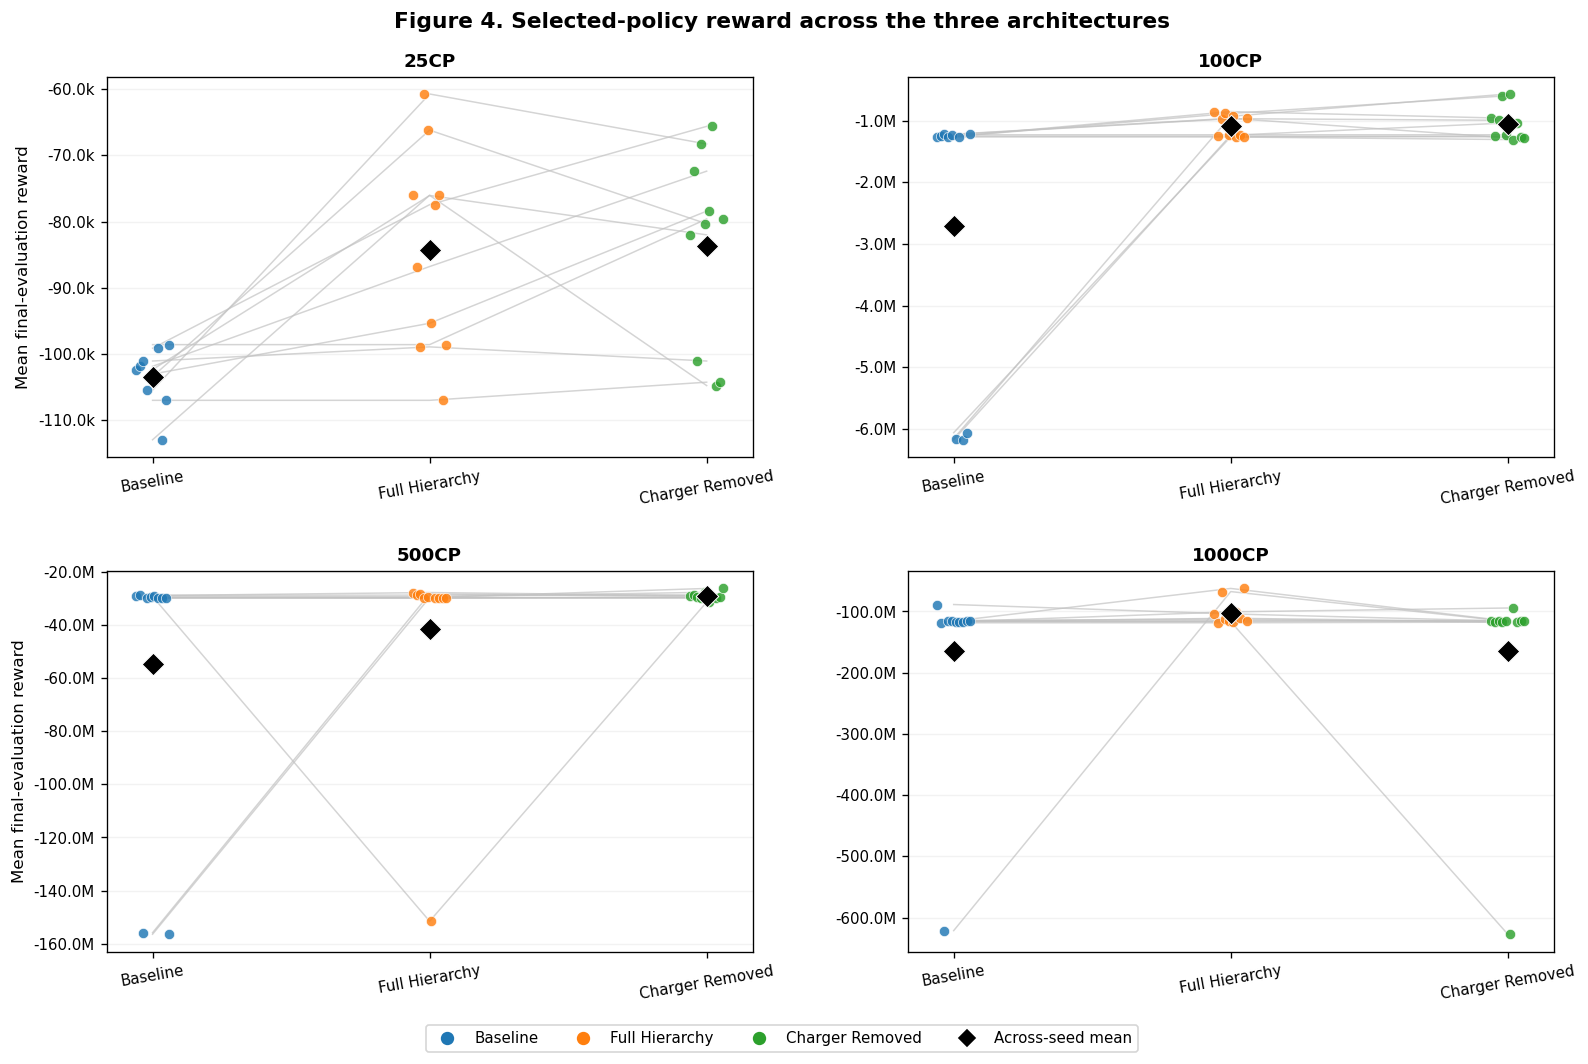

In [10]:
reward_summary = (
    policy_eval
    .groupby(["scale", "architecture"], observed=True)["episode_reward"]
    .agg(["mean", "std"])
    .reset_index()
)

reward_table_rows = []
for scale in SCALE_ORDER:
    row = {"Scenario": SCALE_LABELS[scale]}
    for architecture in ARCH_ORDER:
        r = reward_summary[
            (reward_summary["scale"] == scale)
            & (reward_summary["architecture"] == architecture)
        ].iloc[0]
        row[ARCH_SHORT[architecture]] = (
            f"{compact_number(r['mean'])} ± {compact_number(r['std'])}"
        )
    reward_table_rows.append(row)

display(pd.DataFrame(reward_table_rows))

fig, axes = plt.subplots(2, 2, figsize=(13.4, 9.0))
fig.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.11, hspace=0.30, wspace=0.24)

for ax, scale in zip(axes.ravel(), SCALE_ORDER):
    d = policy_eval[policy_eval["scale"] == scale]
    x = np.arange(len(ARCH_ORDER))

    for seed in range(10):
        seed_values = []
        for architecture in ARCH_ORDER:
            value = d[
                (d["architecture"] == architecture)
                & (d["training_seed"] == seed)
            ]["episode_reward"].iloc[0]
            seed_values.append(value)

        ax.plot(
            x,
            seed_values,
            color="0.76",
            linewidth=0.9,
            alpha=0.70,
            zorder=1,
        )

    for xpos, architecture in zip(x, ARCH_ORDER):
        values = (
            d[d["architecture"] == architecture]
            .sort_values("training_seed")["episode_reward"]
            .to_numpy(float)
        )
        jitter = np.linspace(-0.06, 0.06, len(values))
        ax.scatter(
            xpos + jitter,
            values,
            s=38,
            color=ARCH_COLOUR[architecture],
            alpha=0.82,
            edgecolor="white",
            linewidth=0.45,
            zorder=3,
        )
        ax.scatter(
            xpos,
            values.mean(),
            s=92,
            marker="D",
            color="black",
            edgecolor="white",
            linewidth=0.6,
            zorder=4,
        )

    ax.set_xticks(x, [ARCH_SHORT[a] for a in ARCH_ORDER], rotation=10)
    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.yaxis.set_major_formatter(COMPACT_FORMATTER)
    ax.grid(axis="y", alpha=0.16)

axes[0, 0].set_ylabel("Mean final-evaluation reward")
axes[1, 0].set_ylabel("Mean final-evaluation reward")

legend = [
    Line2D([0], [0], marker="o", linestyle="", markersize=7,
           color=ARCH_COLOUR[a], label=ARCH_SHORT[a])
    for a in ARCH_ORDER
]
legend.append(
    Line2D([0], [0], marker="D", linestyle="", markersize=7,
           color="black", label="Across-seed mean")
)
fig.legend(
    handles=legend,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=4,
    frameon=True,
)
fig.suptitle(
    "Figure 4. Selected-policy reward across the three architectures",
    fontsize=13,
    fontweight="bold",
)
plt.show()

### What Figure 4 shows

At 25CP, the two hierarchical variants occupy almost the same reward region and both sit above the direct-action baseline for most seeds.

At 100CP, both hierarchical variants again have much less negative mean reward than the baseline, although the exact seed-by-seed ordering between the two hierarchical variants is mixed.

At 500CP and 1000CP, the most important feature is no longer the group mean alone. A small number of severe seed-level failures stretch the distribution and can strongly move the average. Those tails are examined explicitly below.

### Secondary control quantities

Reward is the primary control outcome because the canonical final-evaluation tables satisfy:

\[
\text{episode reward} = -\,\text{tracking error}.
\]

Reward and tracking error are therefore the same control signal expressed with opposite sign and should not be counted as two independent findings.

Energy-tracking error and power-tracker violation remain distinct secondary control quantities. The following table shows their selected-policy means for context.

In [11]:
secondary_control = (
    policy_eval
    .groupby(["scale", "architecture"], observed=True)[
        ["energy_tracking_error", "power_tracker_violation"]
    ]
    .mean()
    .reset_index()
)

rows = []
for scale in SCALE_ORDER:
    for architecture in ARCH_ORDER:
        r = secondary_control[
            (secondary_control["scale"] == scale)
            & (secondary_control["architecture"] == architecture)
        ].iloc[0]
        rows.append({
            "Scenario": SCALE_LABELS[scale],
            "Architecture": ARCH_SHORT[architecture],
            "Mean energy-tracking error": compact_number(r["energy_tracking_error"]),
            "Mean power-tracker violation": compact_number(r["power_tracker_violation"]),
        })

display(pd.DataFrame(rows))

,Scenario,Architecture,Mean energy-tracking error,Mean power-tracker violation
0,25CP,Baseline,650.40,785.78
1,25CP,Full Hierarchy,581.34,598.50
2,25CP,Charger Removed,583.52,566.97
3,100CP,Baseline,3.2k,2.5k
4,100CP,Full Hierarchy,2.1k,3.1k
5,100CP,Charger Removed,2.1k,2.9k
6,500CP,Baseline,14.3k,13.7k
7,500CP,Full Hierarchy,12.5k,14.5k
8,500CP,Charger Removed,10.8k,15.0k
9,1000CP,Baseline,24.9k,29.3k


# Primary architecture-attribution contrast
## Full Hierarchy vs Charger-Level Allocation Removed

The primary ablation effect is defined as:

\[
\Delta R
=
R_{\text{removal}}
-
R_{\text{full}}.
\]

Positive values favour the architecture with the charger-level allocation removed; negative values favour the full hierarchy.

This comparison directly asks whether the explicit charger stage changes the selected-policy reward once transformer-level hierarchical decision formation is retained.

In [12]:
display(
    reward_stats_table(
        removal_vs_full_reward,
        "Charger Removed",
    )
)

,Scenario,Mean paired reward effect,95% CI,Median effect,Seeds favouring Charger Removed,Paired t p,Exact sign-flip p,Holm p
0,25CP,+636.78,"[-10.35k, +11.62k]",+302.95,5/10,0.8986,0.8945,1.0000
1,100CP,+35.33k,"[-106.68k, +177.35k]",-382.89,3/10,0.5873,0.5938,1.0000
2,500CP,+12.33M,"[-14.77M, +39.44M]",+10.77k,6/10,0.3303,0.2715,0.9908
3,1000CP,-62.70M,"[-176.20M, +50.79M]",-5.32M,4/10,0.2429,0.0625,0.9716


Across the four formal scenarios, **no Full-Hierarchy-vs-Charger-Removal mean reward difference is statistically resolved after the four-scale Holm correction**.

That is not an equivalence result. It means that with ten paired trained policies per scenario, the data do not resolve a non-zero mean reward difference between the two hierarchical variants at the pre-specified family level.

The seed-level pattern is still important, because the 500CP and 1000CP means are strongly affected by extreme policies.

## Figure 5 — Same-seed Full-Hierarchy vs Charger-Removal reward

The next figure keeps each training seed visible. A horizontal line joins the Full Hierarchy and Charger-Removed policy that share the same seed label.

This makes two things immediately visible:

- whether most paired seeds move in the same direction;
- whether the mean effect is being driven by one unusually large paired difference.

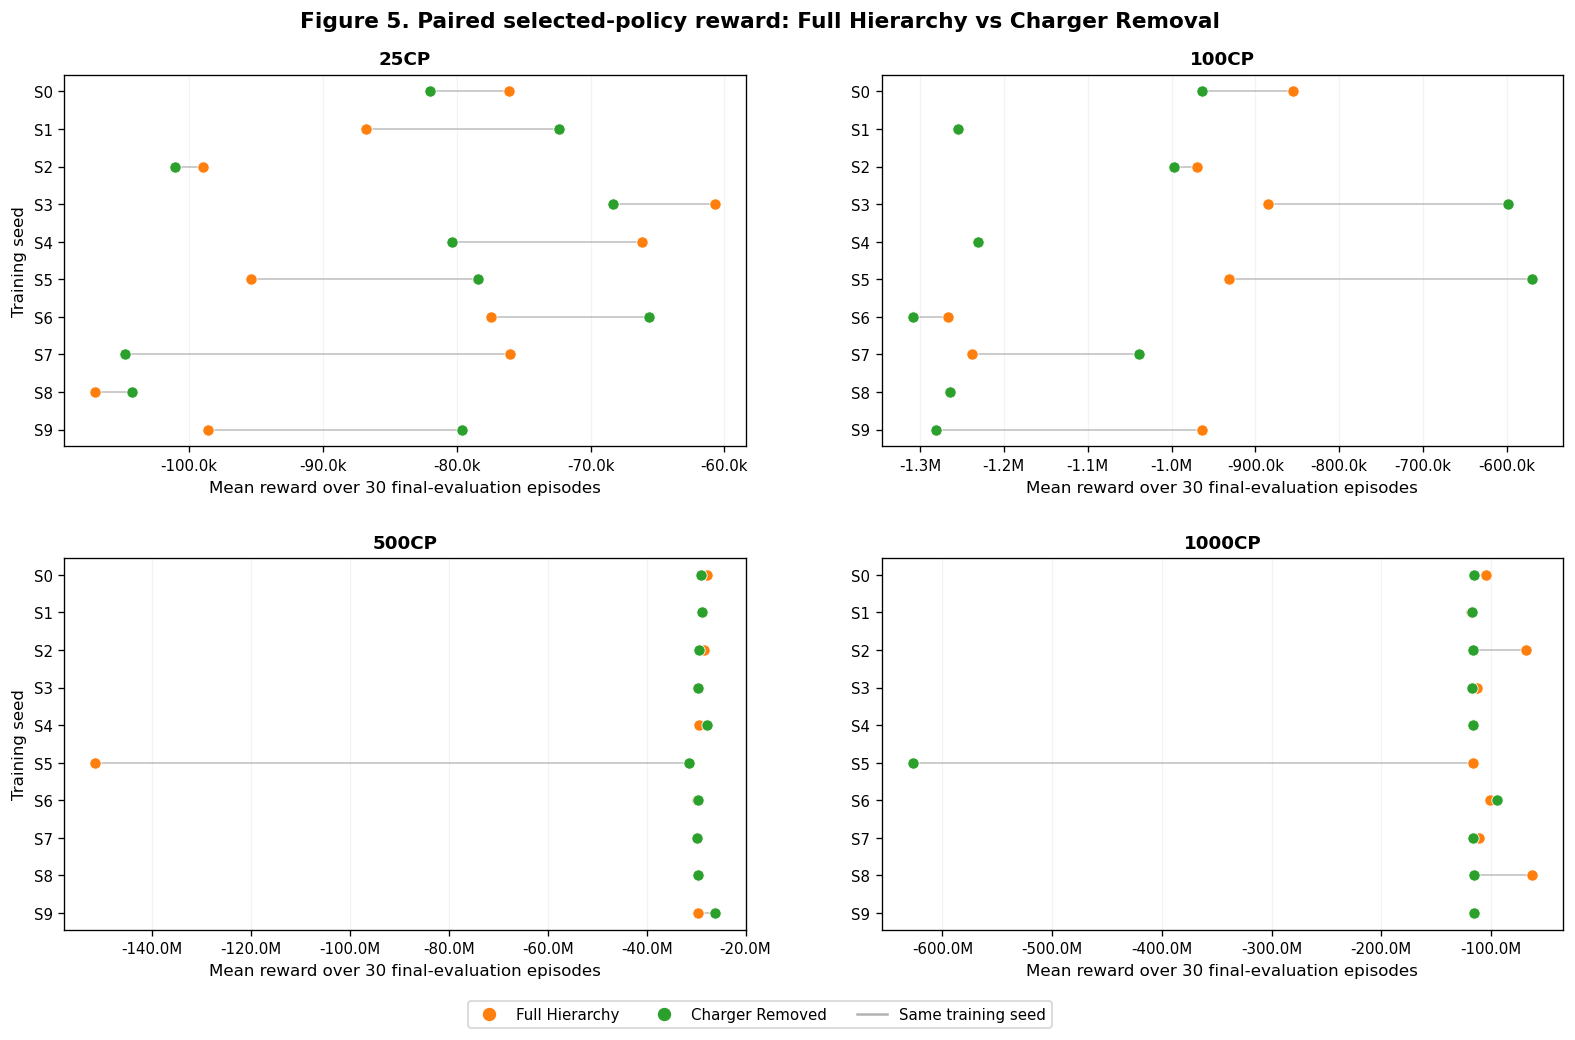

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13.8, 8.8))
fig.subplots_adjust(left=0.08, right=0.985, top=0.92, bottom=0.11, hspace=0.30, wspace=0.20)

for ax, scale in zip(axes.ravel(), SCALE_ORDER):
    full = (
        policy_eval[
            (policy_eval["scale"] == scale)
            & (policy_eval["architecture"] == "full")
        ]
        .set_index("training_seed")["episode_reward"]
        .sort_index()
    )
    removal = (
        policy_eval[
            (policy_eval["scale"] == scale)
            & (policy_eval["architecture"] == "removal")
        ]
        .set_index("training_seed")["episode_reward"]
        .sort_index()
    )

    seeds = full.index.to_numpy(int)
    y = np.arange(len(seeds))

    for yi, f, r in zip(y, full, removal):
        ax.plot([f, r], [yi, yi], color="0.76", linewidth=1.0, zorder=1)

    ax.scatter(
        full, y,
        s=46,
        color=ARCH_COLOUR["full"],
        edgecolor="white",
        linewidth=0.5,
        label="Full Hierarchy",
        zorder=3,
    )
    ax.scatter(
        removal, y,
        s=46,
        color=ARCH_COLOUR["removal"],
        edgecolor="white",
        linewidth=0.5,
        label="Charger Removed",
        zorder=3,
    )

    ax.set_yticks(y, [f"S{s}" for s in seeds])
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(COMPACT_FORMATTER)
    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.set_xlabel("Mean reward over 30 final-evaluation episodes")
    ax.grid(axis="x", alpha=0.15)

axes[0, 0].set_ylabel("Training seed")
axes[1, 0].set_ylabel("Training seed")

handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=7,
           color=ARCH_COLOUR["full"], label="Full Hierarchy"),
    Line2D([0], [0], marker="o", linestyle="", markersize=7,
           color=ARCH_COLOUR["removal"], label="Charger Removed"),
    Line2D([0], [0], color="0.70", lw=1.5, label="Same training seed"),
]
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    frameon=True,
)
fig.suptitle(
    "Figure 5. Paired selected-policy reward: Full Hierarchy vs Charger Removal",
    fontsize=13,
    fontweight="bold",
)
plt.show()

### Scenario-by-scenario interpretation

- **25CP:** the two hierarchical variants are extremely close on average. Five paired seeds favour removal and five favour the full hierarchy.
- **100CP:** the mean difference is again small relative to seed variation; only three paired seeds favour removal.
- **500CP:** the mean appears strongly favourable to removal, but the paired lines reveal that this is not a uniform shift.
- **1000CP:** the mean reverses strongly against removal, again because one policy sits far outside the typical range.

This is why the next section separates the **mean effect** from the **failure-tail structure**.

# Seed heterogeneity and failure tails
## Figure 6 — Why the 500CP and 1000CP means need special interpretation

A large mean difference can arise in two very different ways:

1. most seeds shift by a similar amount; or
2. one extreme seed dominates the average.

The paired median helps distinguish these cases because it is much less sensitive to one catastrophic policy.

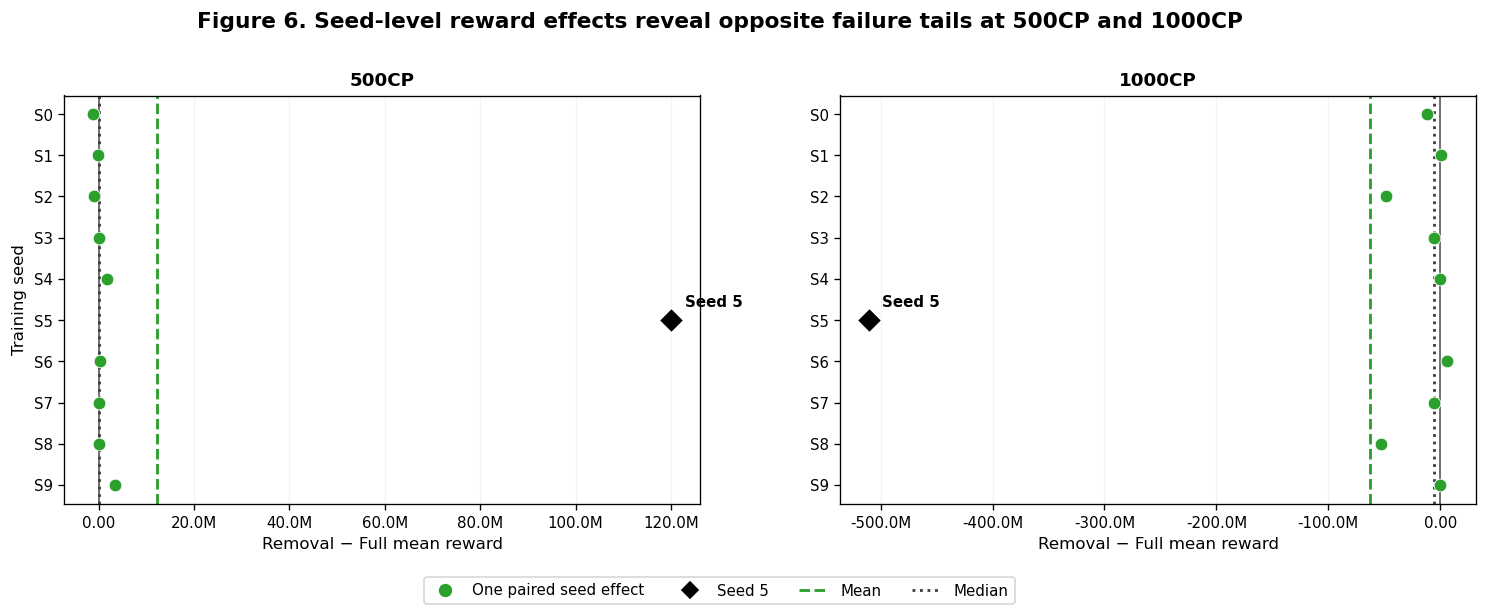

,Scenario,Full seed 5,Removal seed 5,Seed-5 paired effect,Mean paired effect,Median paired effect,Full across-seed SD,Removal across-seed SD
0,500CP,-151.5M,-31.4M,+120.10M,+12.33M,+10.77k,38.7M,1.4M
1,1000CP,-116.8M,-627.1M,-510.33M,-62.70M,-5.32M,20.6M,162.4M


In [14]:
tail_scales = ["500cp", "1000cp"]
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
fig.subplots_adjust(left=0.08, right=0.985, top=0.84, bottom=0.16, wspace=0.22)

for ax, scale in zip(axes, tail_scales):
    full = (
        policy_eval[
            (policy_eval["scale"] == scale)
            & (policy_eval["architecture"] == "full")
        ]
        .set_index("training_seed")["episode_reward"]
        .sort_index()
    )
    removal = (
        policy_eval[
            (policy_eval["scale"] == scale)
            & (policy_eval["architecture"] == "removal")
        ]
        .set_index("training_seed")["episode_reward"]
        .sort_index()
    )

    diff = removal - full
    seeds = diff.index.to_numpy(int)

    ax.axvline(0, color="0.35", linewidth=1.0)
    ax.scatter(
        diff,
        seeds,
        s=58,
        color=ARCH_COLOUR["removal"],
        edgecolor="white",
        linewidth=0.5,
        zorder=3,
    )

    seed5_value = diff.loc[5]
    ax.scatter(
        seed5_value,
        5,
        s=105,
        marker="D",
        color="black",
        edgecolor="white",
        linewidth=0.7,
        zorder=4,
    )
    ax.annotate(
        "Seed 5",
        (seed5_value, 5),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight="semibold",
    )

    ax.axvline(
        diff.mean(),
        color=ARCH_COLOUR["removal"],
        linewidth=1.7,
        linestyle="--",
        label="Mean paired effect",
    )
    ax.axvline(
        diff.median(),
        color="0.25",
        linewidth=1.7,
        linestyle=":",
        label="Median paired effect",
    )

    ax.set_yticks(range(10), [f"S{i}" for i in range(10)])
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(COMPACT_FORMATTER)
    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.set_xlabel("Removal − Full mean reward")
    ax.grid(axis="x", alpha=0.15)

axes[0].set_ylabel("Training seed")
fig.legend(
    handles=[
        Line2D([0], [0], marker="o", linestyle="", markersize=7,
               color=ARCH_COLOUR["removal"], label="One paired seed effect"),
        Line2D([0], [0], marker="D", linestyle="", markersize=7,
               color="black", label="Seed 5"),
        Line2D([0], [0], color=ARCH_COLOUR["removal"], lw=1.7,
               linestyle="--", label="Mean"),
        Line2D([0], [0], color="0.25", lw=1.7,
               linestyle=":", label="Median"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    frameon=True,
)
fig.suptitle(
    "Figure 6. Seed-level reward effects reveal opposite failure tails at 500CP and 1000CP",
    fontsize=13,
    fontweight="bold",
)
plt.show()

tail_rows = []
for scale in tail_scales:
    full = (
        policy_eval[
            (policy_eval["scale"] == scale)
            & (policy_eval["architecture"] == "full")
        ]
        .set_index("training_seed")["episode_reward"]
        .sort_index()
    )
    removal = (
        policy_eval[
            (policy_eval["scale"] == scale)
            & (policy_eval["architecture"] == "removal")
        ]
        .set_index("training_seed")["episode_reward"]
        .sort_index()
    )
    diff = removal - full
    tail_rows.append({
        "Scenario": SCALE_LABELS[scale],
        "Full seed 5": compact_number(full.loc[5]),
        "Removal seed 5": compact_number(removal.loc[5]),
        "Seed-5 paired effect": signed_compact(diff.loc[5]),
        "Mean paired effect": signed_compact(diff.mean()),
        "Median paired effect": signed_compact(diff.median()),
        "Full across-seed SD": compact_number(full.std(ddof=1)),
        "Removal across-seed SD": compact_number(removal.std(ddof=1)),
    })

display(pd.DataFrame(tail_rows))

### 500CP: the mean advantage is mainly a tail rescue

At 500CP, the mean Removal-minus-Full reward effect is about \(+12.3\) million, but the median paired effect is only around \(+10.8\) thousand. The difference comes largely from Full-Hierarchy seed 5, whose selected-policy reward collapses far below the other full-hierarchy seeds while the corresponding charger-removed seed remains in the main performance cluster.

The correct interpretation is therefore **not** that removing the charger layer uniformly improves 500CP policies. The stronger statement supported by the seed-level evidence is that the reduced hierarchy avoids one severe full-hierarchy failure in this configuration.

### 1000CP: the opposite failure tail appears

At 1000CP, the direction reverses. Charger-Removed seed 5 suffers a very large reward collapse while the Full-Hierarchy seed 5 remains much closer to the other full-hierarchy runs.

This pattern is consistent with the charger stage having a **configuration-specific stabilising role** at 1000CP, but the experiment does not establish a universally stabilising charger layer: the mean Full-vs-Removal reward effect itself remains statistically unresolved.

# Decision mechanism: active-EV action composition

The strongest architecture-attribution question is not whether the two hierarchical variants have identical reward. It is whether the **behavioural mechanism discovered in the original Formal75K study** survives after the charger-level allocation is removed.

For every active-EV decision, the action is separated into:

- **zero:** no charging command;
- **interior:** positive charging below the upper bound;
- **maximum:** charging at the upper action boundary.

A boundary-dominated policy uses very little of the interior of the continuous action range. A more graded policy makes substantial use of intermediate charging levels.

### Preparing the action-composition comparison

The next code cell averages the diagnostic action fractions within each trained seed and then summarises the ten independently trained policies.

The physically comparable charger-level concentration metric in the reduced architecture is a **charger-group positive charging-action concentration** measure. It should not be interpreted as an internal learned charger-allocation-head weight, because that explicit head has been removed.

In [15]:
action_summary = (
    policy_diag
    .groupby(["scale", "architecture"], observed=True)[
        ["active_zero_fraction", "active_interior_fraction", "active_max_fraction"]
    ]
    .mean()
    .reset_index()
)

action_rows = []
for scale in SCALE_ORDER:
    row = {"Scenario": SCALE_LABELS[scale]}
    for architecture in ARCH_ORDER:
        d = action_summary[
            (action_summary["scale"] == scale)
            & (action_summary["architecture"] == architecture)
        ].iloc[0]
        row[f"{ARCH_SHORT[architecture]} max"] = percent_text(d["active_max_fraction"], 2)
        row[f"{ARCH_SHORT[architecture]} interior"] = percent_text(d["active_interior_fraction"], 2)

    removal = (
        policy_diag[
            (policy_diag["scale"] == scale)
            & (policy_diag["architecture"] == "removal")
        ]
        .set_index("training_seed")["active_interior_fraction"]
        .sort_index()
    )
    baseline = (
        policy_diag[
            (policy_diag["scale"] == scale)
            & (policy_diag["architecture"] == "baseline")
        ]
        .set_index("training_seed")["active_interior_fraction"]
        .sort_index()
    )
    diff = removal - baseline
    row["Removal − Baseline interior"] = f"{100 * diff.mean():+.2f} pp"
    row["Seeds Removal > Baseline"] = f"{int((diff > 0).sum())}/10"
    action_rows.append(row)

display(pd.DataFrame(action_rows))

,Scenario,Baseline max,Baseline interior,Full Hierarchy max,Full Hierarchy interior,Charger Removed max,Charger Removed interior,Removal − Baseline interior,Seeds Removal > Baseline
0,25CP,99.86%,0.14%,51.04%,46.59%,55.29%,42.04%,+41.89 pp,10/10
1,100CP,68.52%,1.42%,56.39%,41.56%,58.97%,39.07%,+37.66 pp,10/10
2,500CP,79.98%,0.02%,47.79%,41.83%,45.91%,54.04%,+54.02 pp,10/10
3,1000CP,84.87%,4.89%,57.55%,42.07%,48.62%,41.53%,+36.65 pp,10/10


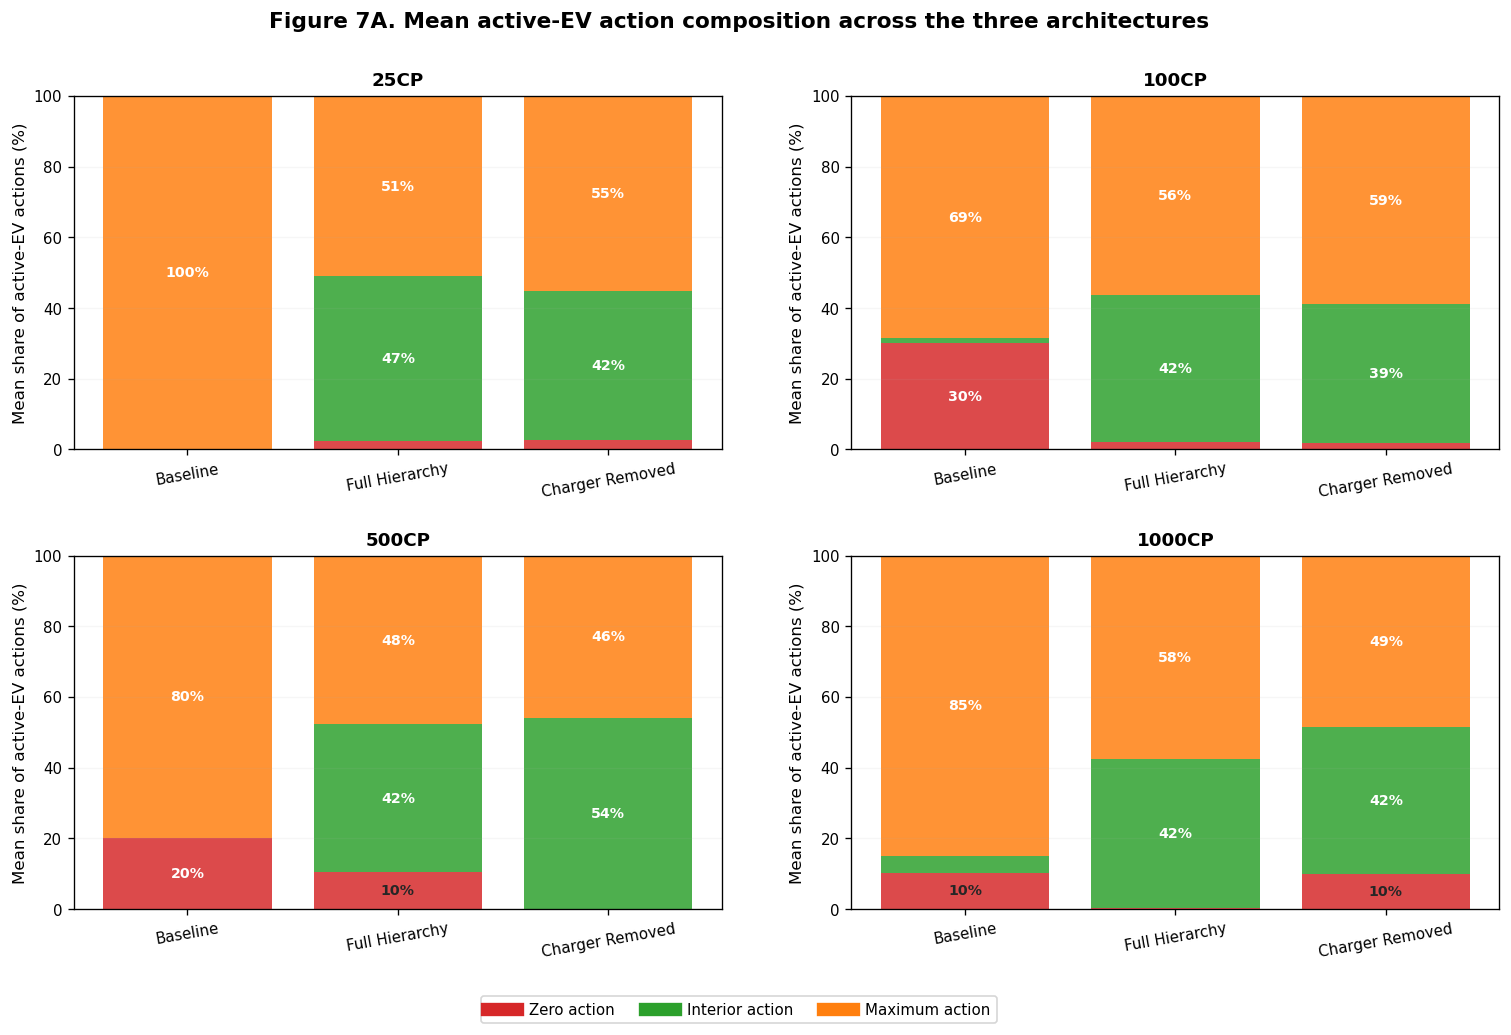

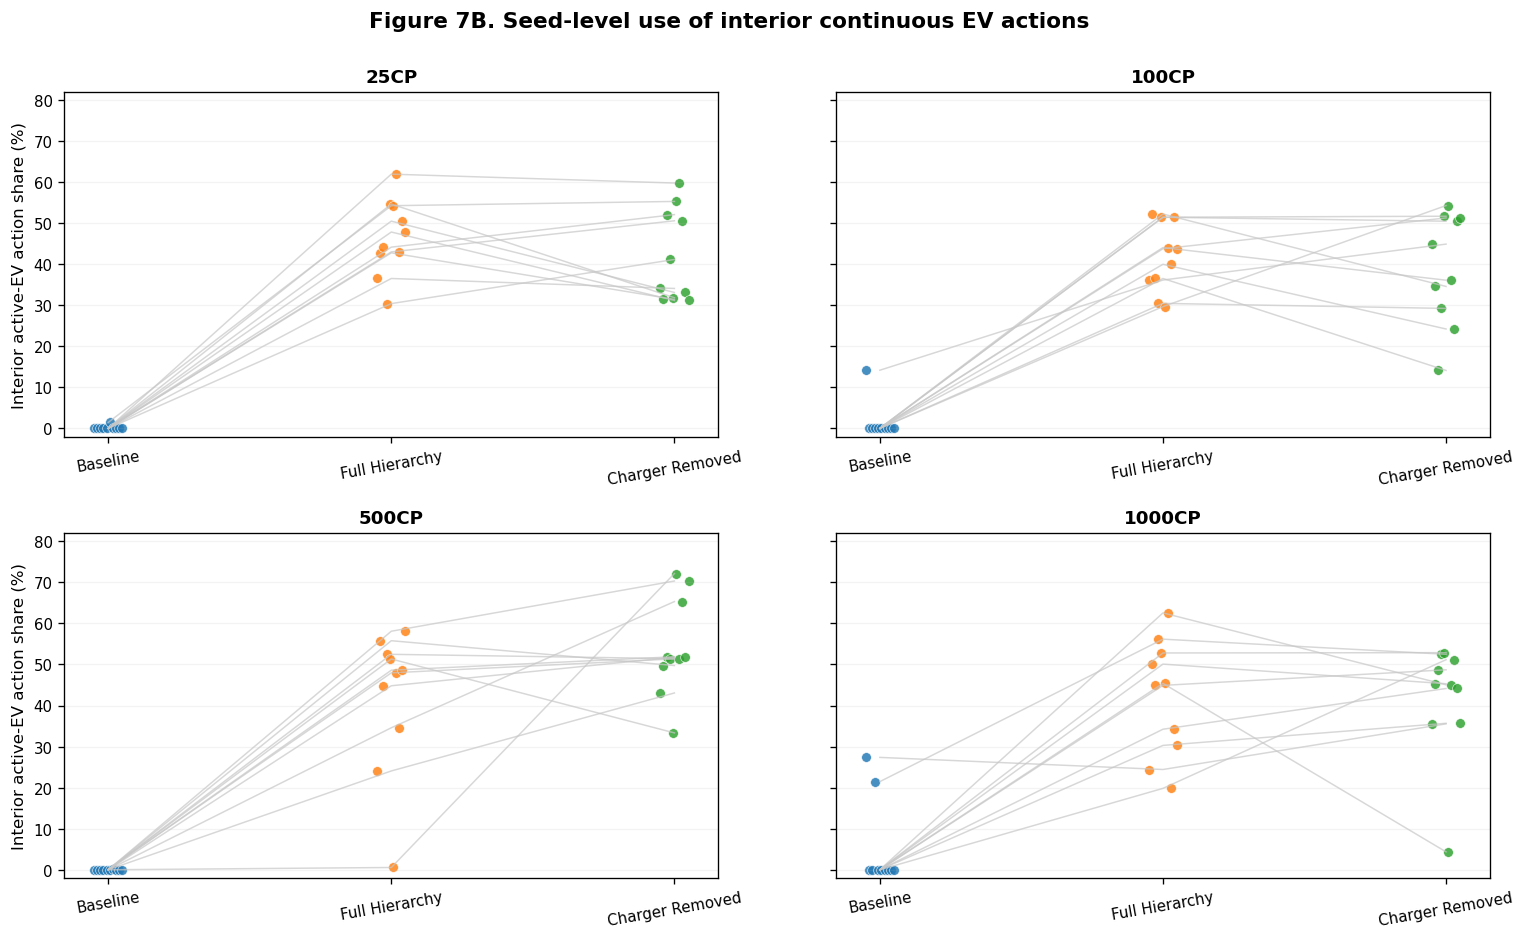

In [16]:
# Figure 7A: mean action composition.
fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.8))
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.13, hspace=0.30, wspace=0.20)

for ax, scale in zip(axes.ravel(), SCALE_ORDER):
    d = (
        action_summary[action_summary["scale"] == scale]
        .set_index("architecture")
        .loc[ARCH_ORDER]
    )

    x = np.arange(len(ARCH_ORDER))
    zero = 100 * d["active_zero_fraction"].to_numpy(float)
    interior = 100 * d["active_interior_fraction"].to_numpy(float)
    maximum = 100 * d["active_max_fraction"].to_numpy(float)

    ax.bar(
        x, zero,
        color=COMPONENT_COLOUR["Zero action"],
        alpha=0.84,
        label="Zero action",
    )
    ax.bar(
        x, interior,
        bottom=zero,
        color=COMPONENT_COLOUR["Interior action"],
        alpha=0.84,
        label="Interior action",
    )
    ax.bar(
        x, maximum,
        bottom=zero + interior,
        color=COMPONENT_COLOUR["Maximum action"],
        alpha=0.84,
        label="Maximum action",
    )

    for xpos, z, i, m in zip(x, zero, interior, maximum):
        for bottom, value in [(0, z), (z, i), (z + i, m)]:
            if value >= 8:
                ax.text(
                    xpos,
                    bottom + value / 2,
                    f"{value:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    color="white" if value > 18 else "0.15",
                    fontweight="semibold",
                )

    ax.set_xticks(x, [ARCH_SHORT[a] for a in ARCH_ORDER], rotation=10)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Mean share of active-EV actions (%)")
    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.grid(axis="y", alpha=0.10)

handles = [
    Line2D([0], [0], color=COMPONENT_COLOUR[name], lw=8, label=name)
    for name in ["Zero action", "Interior action", "Maximum action"]
]
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=3,
    frameon=True,
)
fig.suptitle(
    "Figure 7A. Mean active-EV action composition across the three architectures",
    fontsize=13,
    fontweight="bold",
)
plt.show()

# Figure 7B: seed-level interior-action use.
fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.4), sharey=True)
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.12, hspace=0.28, wspace=0.18)

for ax, scale in zip(axes.ravel(), SCALE_ORDER):
    d = policy_diag[policy_diag["scale"] == scale]
    x = np.arange(len(ARCH_ORDER))

    for seed in range(10):
        values = [
            d[
                (d["architecture"] == architecture)
                & (d["training_seed"] == seed)
            ]["active_interior_fraction"].iloc[0] * 100
            for architecture in ARCH_ORDER
        ]
        ax.plot(x, values, color="0.78", linewidth=0.9, alpha=0.70)

    for xpos, architecture in zip(x, ARCH_ORDER):
        values = (
            d[d["architecture"] == architecture]
            .sort_values("training_seed")["active_interior_fraction"]
            .to_numpy(float) * 100
        )
        jitter = np.linspace(-0.05, 0.05, len(values))
        ax.scatter(
            xpos + jitter,
            values,
            s=34,
            color=ARCH_COLOUR[architecture],
            alpha=0.82,
            edgecolor="white",
            linewidth=0.4,
        )

    ax.set_xticks(x, [ARCH_SHORT[a] for a in ARCH_ORDER], rotation=10)
    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.set_ylim(-2, 82)
    ax.grid(axis="y", alpha=0.14)

axes[0, 0].set_ylabel("Interior active-EV action share (%)")
axes[1, 0].set_ylabel("Interior active-EV action share (%)")
fig.suptitle(
    "Figure 7B. Seed-level use of interior continuous EV actions",
    fontsize=13,
    fontweight="bold",
)
plt.show()

## What the action-composition result means

The Baseline remains strongly boundary-dominated, especially at 25CP, 500CP, and 1000CP. Both hierarchical variants make far greater use of the interior of the continuous action range.

Crucially, the charger-removed architecture preserves this mechanism:

- the interior-action increase relative to the Baseline remains roughly **37–54 percentage points** across the four scenarios;
- all ten paired training seeds favour Charger Removal over the Baseline for interior-action use at every scale.

Because transformer-level hierarchy is retained while explicit charger-level allocation is removed, this result supports a controlled attribution:

> **Explicit charger-level allocation is not necessary for the principal graded-action mechanism.**

That does not mean interior actions are automatically better. The action mechanism still has to be interpreted alongside control reward, transformer stress, and EV service.

# Infrastructure allocation and transformer stress

The original hierarchy was designed around infrastructure structure, but a more structured decision does not automatically imply lower physical stress.

Two different questions are therefore separated:

1. **Where is positive charging action concentrated?** — described by HHI/Gini at transformer and charger-group levels.
2. **How much transformer overload is observed?** — an operational consequence.

HHI is a concentration measure, not a performance score. A higher HHI means positive action is concentrated into fewer groups; a lower HHI means it is distributed more broadly. Neither direction is inherently better without considering the physical operating state.

In [17]:
infrastructure_summary = (
    policy_diag
    .groupby(["scale", "architecture"], observed=True)[
        ["transformer_overload", "transformer_hhi", "charger_group_hhi"]
    ]
    .mean()
    .reset_index()
)

infra_rows = []
for scale in SCALE_ORDER:
    for architecture in ARCH_ORDER:
        r = infrastructure_summary[
            (infrastructure_summary["scale"] == scale)
            & (infrastructure_summary["architecture"] == architecture)
        ].iloc[0]
        infra_rows.append({
            "Scenario": SCALE_LABELS[scale],
            "Architecture": ARCH_SHORT[architecture],
            "Mean transformer overload": compact_number(r["transformer_overload"]),
            "Transformer HHI": f"{r['transformer_hhi']:.3f}",
            "Charger-group HHI": f"{r['charger_group_hhi']:.3f}",
        })

display(pd.DataFrame(infra_rows))

,Scenario,Architecture,Mean transformer overload,Transformer HHI,Charger-group HHI
0,25CP,Baseline,0.02,0.387,0.115
1,25CP,Full Hierarchy,0.08,0.421,0.149
2,25CP,Charger Removed,0.11,0.426,0.150
3,100CP,Baseline,20.63,0.175,0.046
4,100CP,Full Hierarchy,70.63,0.195,0.063
5,100CP,Charger Removed,50.24,0.192,0.062
6,500CP,Baseline,111.96,0.146,0.088
7,500CP,Full Hierarchy,117.30,0.125,0.093
8,500CP,Charger Removed,119.57,0.041,0.014
9,1000CP,Baseline,252.20,0.021,0.007


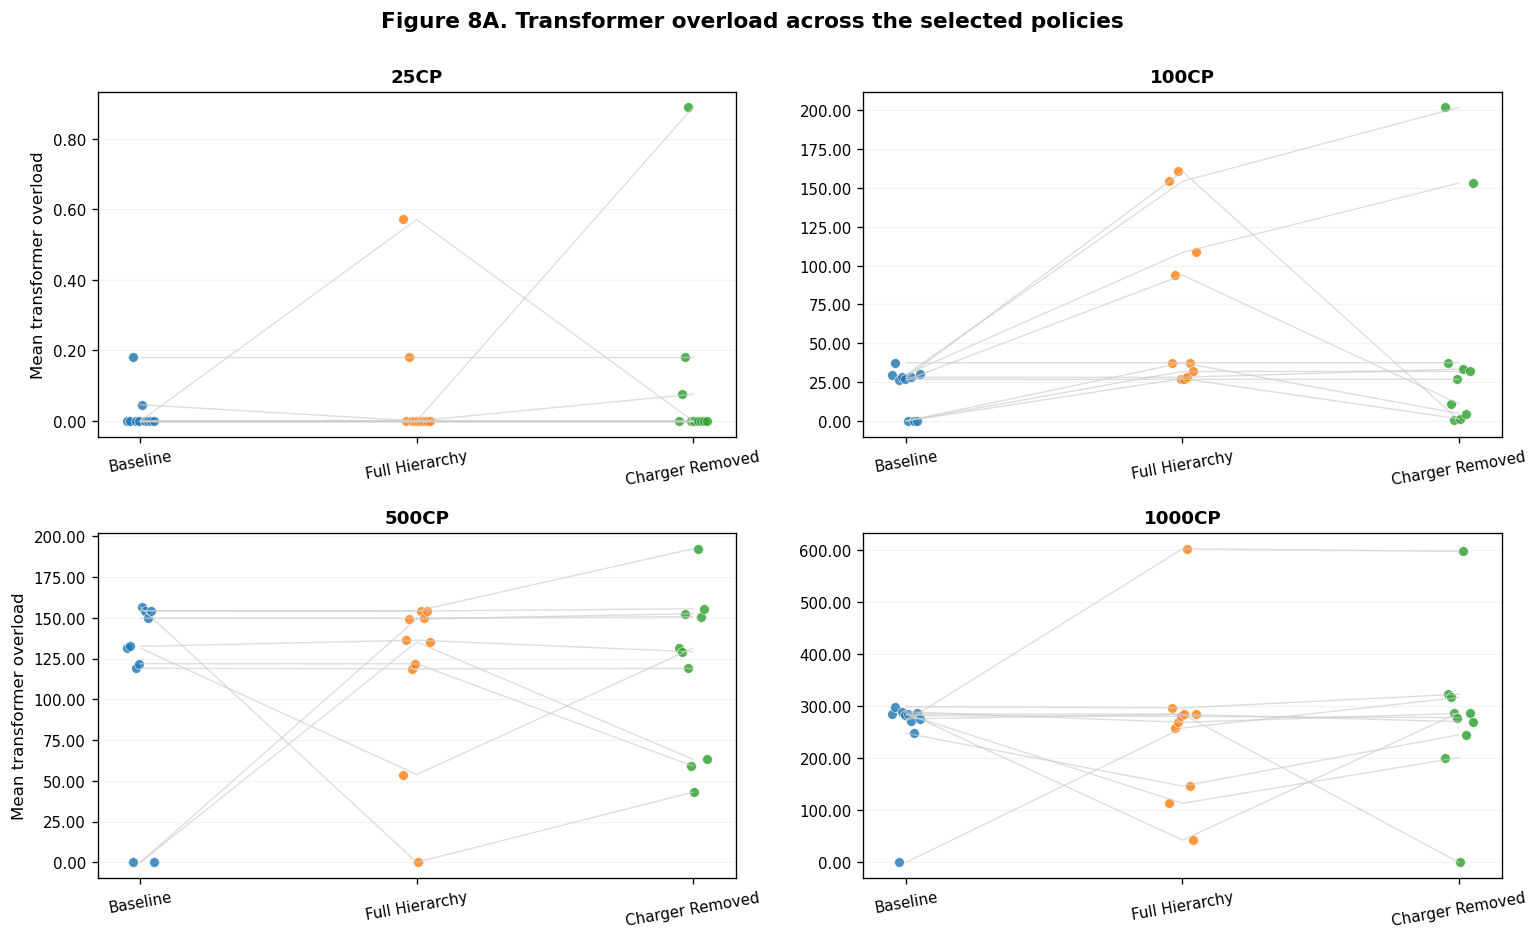

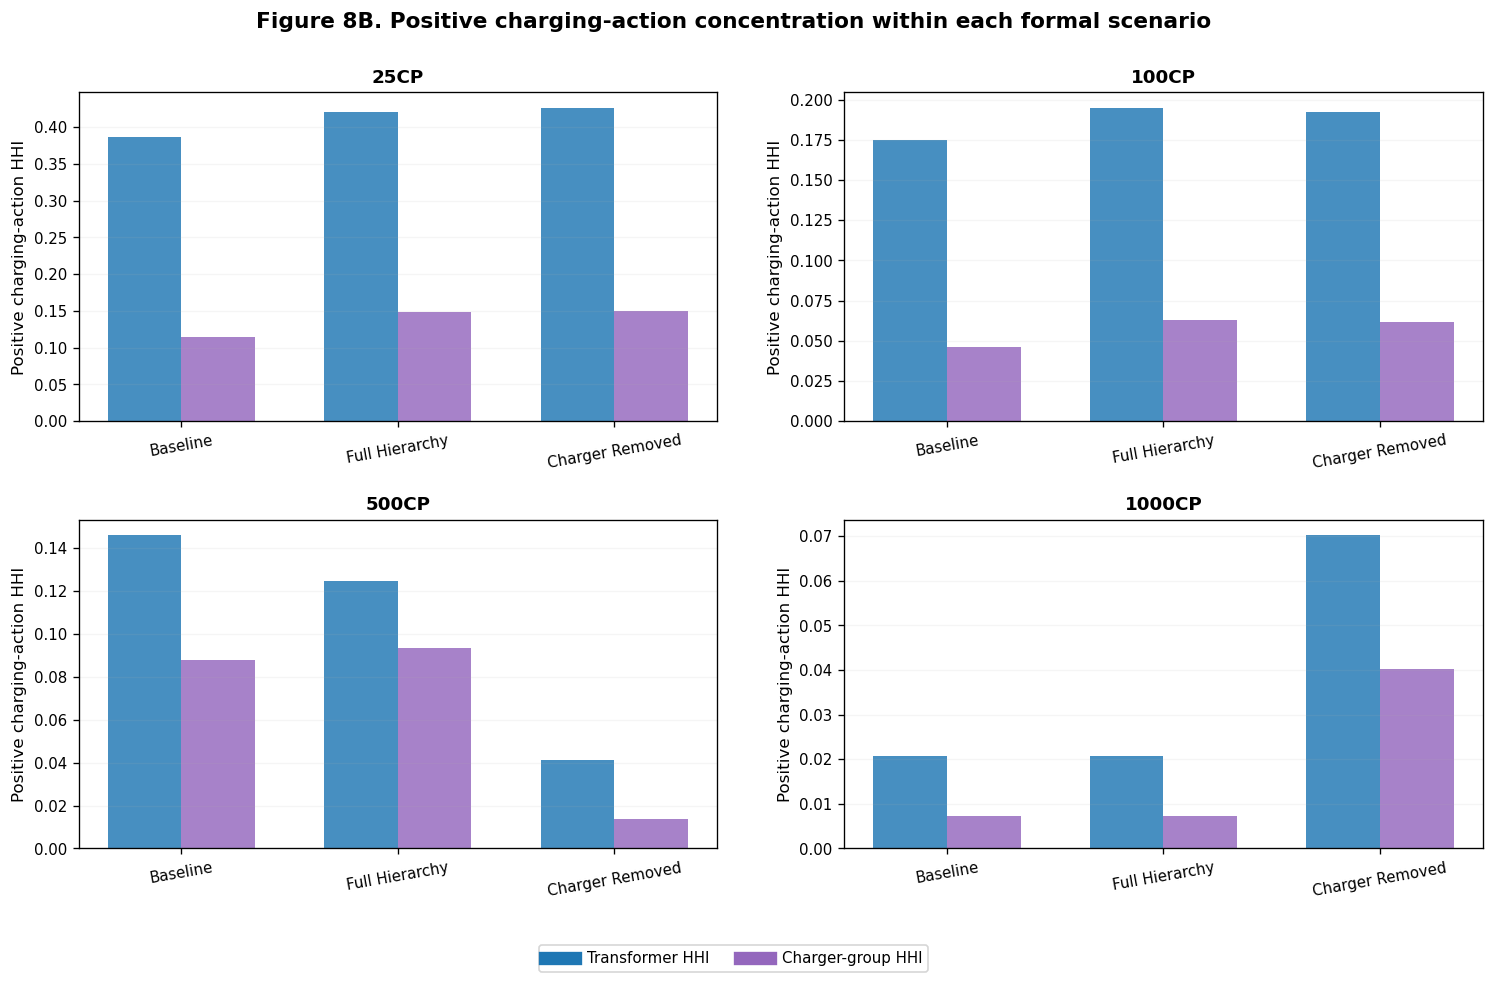

In [18]:
# Figure 8A: seed-level transformer overload.
fig, axes = plt.subplots(2, 2, figsize=(13.0, 8.4))
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.12, hspace=0.28, wspace=0.20)

for ax, scale in zip(axes.ravel(), SCALE_ORDER):
    d = policy_diag[policy_diag["scale"] == scale]
    x = np.arange(len(ARCH_ORDER))

    for seed in range(10):
        values = [
            d[
                (d["architecture"] == architecture)
                & (d["training_seed"] == seed)
            ]["transformer_overload"].iloc[0]
            for architecture in ARCH_ORDER
        ]
        ax.plot(x, values, color="0.80", linewidth=0.85, alpha=0.65)

    for xpos, architecture in zip(x, ARCH_ORDER):
        values = (
            d[d["architecture"] == architecture]
            .sort_values("training_seed")["transformer_overload"]
            .to_numpy(float)
        )
        jitter = np.linspace(-0.05, 0.05, len(values))
        ax.scatter(
            xpos + jitter,
            values,
            s=34,
            color=ARCH_COLOUR[architecture],
            alpha=0.82,
            edgecolor="white",
            linewidth=0.4,
        )

    ax.set_xticks(x, [ARCH_SHORT[a] for a in ARCH_ORDER], rotation=10)
    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.yaxis.set_major_formatter(COMPACT_FORMATTER)
    ax.grid(axis="y", alpha=0.14)

axes[0, 0].set_ylabel("Mean transformer overload")
axes[1, 0].set_ylabel("Mean transformer overload")
fig.suptitle(
    "Figure 8A. Transformer overload across the selected policies",
    fontsize=13,
    fontweight="bold",
)
plt.show()

# Figure 8B: transformer and charger-group positive-action concentration.
fig, axes = plt.subplots(2, 2, figsize=(13.0, 8.4), sharey=False)
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.15, hspace=0.30, wspace=0.20)

width = 0.34
for ax, scale in zip(axes.ravel(), SCALE_ORDER):
    d = (
        infrastructure_summary[infrastructure_summary["scale"] == scale]
        .set_index("architecture")
        .loc[ARCH_ORDER]
    )
    x = np.arange(len(ARCH_ORDER))

    ax.bar(
        x - width / 2,
        d["transformer_hhi"],
        width=width,
        color=_cycle[0],
        alpha=0.82,
        label="Transformer HHI",
    )
    ax.bar(
        x + width / 2,
        d["charger_group_hhi"],
        width=width,
        color=_cycle[4],
        alpha=0.82,
        label="Charger-group HHI",
    )

    ax.set_xticks(x, [ARCH_SHORT[a] for a in ARCH_ORDER], rotation=10)
    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.set_ylabel("Positive charging-action HHI")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.12)

fig.legend(
    handles=[
        Line2D([0], [0], color=_cycle[0], lw=8, label="Transformer HHI"),
        Line2D([0], [0], color=_cycle[4], lw=8, label="Charger-group HHI"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=True,
)
fig.suptitle(
    "Figure 8B. Positive charging-action concentration within each formal scenario",
    fontsize=13,
    fontweight="bold",
)
plt.show()

### Infrastructure interpretation

Charger removal does **not** consistently reduce transformer overload. The 100CP mean overload is lower than under the Full Hierarchy, but it remains above the Baseline mean. At 500CP the Full and Charger-Removed means are very similar, while the 1000CP Charger-Removed mean is higher.

The allocation-concentration pattern is also configuration-dependent. At 500CP, the charger-removed policy has much lower transformer and charger-group HHI than the Full Hierarchy; at 1000CP the direction reverses.

That reversal is mechanistically interesting, but it should not be turned into a causal story that "lower HHI caused better reward." The experiment shows that the architecture changes the concentration pattern; it does not isolate HHI itself as the cause of the reward tails.

# EV-service outcomes

A controller can improve aggregate tracking while still changing the experience of individual EV users. The service analysis therefore keeps three quantities visible:

- average user satisfaction;
- total energy delivered;
- number of EVs served.

The formal question is not whether one architecture wins every service metric, but whether removing the charger-level allocation produces a consistent user-level trade-off.

,Scenario,Architecture,Mean satisfaction,Mean energy delivered,Mean EVs served
0,25CP,Baseline,99.86%,1.2k,59.8
1,25CP,Full Hierarchy,99.68%,1.2k,59.8
2,25CP,Charger Removed,99.49%,1.2k,59.8
3,100CP,Baseline,93.13%,3.5k,240.2
4,100CP,Full Hierarchy,99.68%,4.9k,240.2
5,100CP,Charger Removed,99.48%,4.9k,240.2
6,500CP,Baseline,95.37%,19.9k,1197.8
7,500CP,Full Hierarchy,97.42%,22.1k,1197.8
8,500CP,Charger Removed,99.36%,24.1k,1197.8
9,1000CP,Baseline,97.57%,44.6k,2395.9


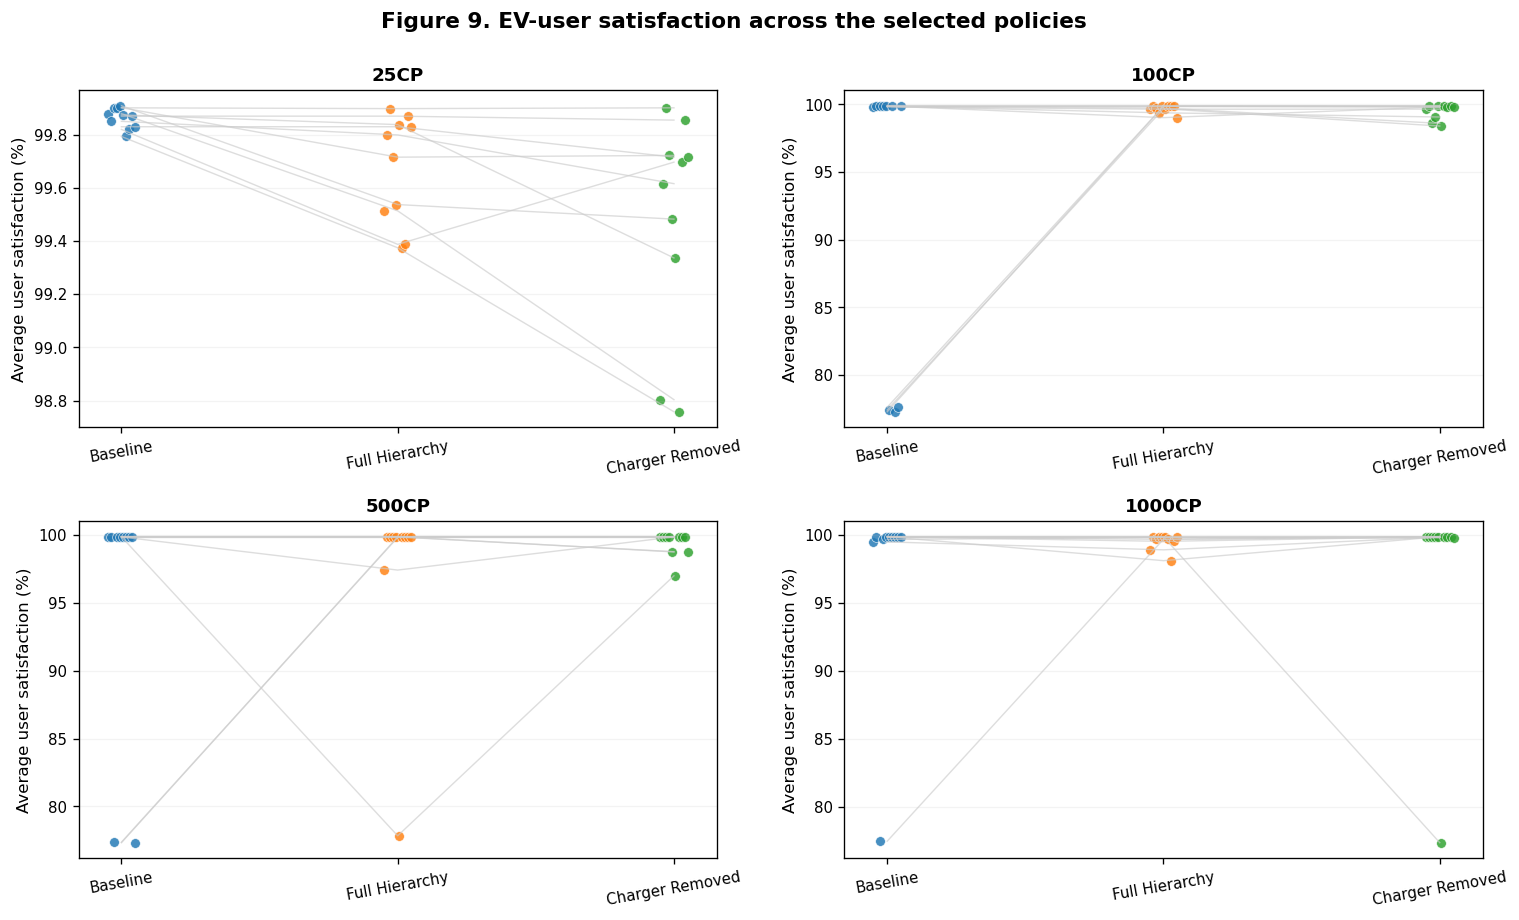

In [19]:
service_summary = (
    policy_eval
    .groupby(["scale", "architecture"], observed=True)[
        ["average_satisfaction", "energy_delivered", "evs_served"]
    ]
    .mean()
    .reset_index()
)

service_rows = []
for scale in SCALE_ORDER:
    for architecture in ARCH_ORDER:
        r = service_summary[
            (service_summary["scale"] == scale)
            & (service_summary["architecture"] == architecture)
        ].iloc[0]
        service_rows.append({
            "Scenario": SCALE_LABELS[scale],
            "Architecture": ARCH_SHORT[architecture],
            "Mean satisfaction": f"{100 * r['average_satisfaction']:.2f}%",
            "Mean energy delivered": compact_number(r["energy_delivered"]),
            "Mean EVs served": f"{r['evs_served']:.1f}",
        })

display(pd.DataFrame(service_rows))

fig, axes = plt.subplots(2, 2, figsize=(13.0, 8.2), sharey=False)
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.12, hspace=0.28, wspace=0.20)

for ax, scale in zip(axes.ravel(), SCALE_ORDER):
    d = policy_eval[policy_eval["scale"] == scale]
    x = np.arange(len(ARCH_ORDER))

    for seed in range(10):
        values = [
            100 * d[
                (d["architecture"] == architecture)
                & (d["training_seed"] == seed)
            ]["average_satisfaction"].iloc[0]
            for architecture in ARCH_ORDER
        ]
        ax.plot(x, values, color="0.80", linewidth=0.85, alpha=0.65)

    for xpos, architecture in zip(x, ARCH_ORDER):
        values = (
            d[d["architecture"] == architecture]
            .sort_values("training_seed")["average_satisfaction"]
            .to_numpy(float) * 100
        )
        jitter = np.linspace(-0.05, 0.05, len(values))
        ax.scatter(
            xpos + jitter,
            values,
            s=34,
            color=ARCH_COLOUR[architecture],
            alpha=0.82,
            edgecolor="white",
            linewidth=0.4,
        )

    ax.set_xticks(x, [ARCH_SHORT[a] for a in ARCH_ORDER], rotation=10)
    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.set_ylabel("Average user satisfaction (%)")
    ax.grid(axis="y", alpha=0.14)

fig.suptitle(
    "Figure 9. EV-user satisfaction across the selected policies",
    fontsize=13,
    fontweight="bold",
)
plt.show()

### Service interpretation

The Full-vs-Removal satisfaction differences are small at 25CP and 100CP, positive on average for removal at 500CP, and negative on average at 1000CP. The larger-scale means are partly shaped by the same extreme policies that dominate the reward tails.

The evidence therefore does not support a universal statement that the charger stage helps or harms EV users. Service remains a separate design dimension that must be considered alongside aggregate tracking and infrastructure stress.

# Directional consistency across the primary ablation outcomes
## Figure 10 — How often does Charger Removal favour the same direction as the Full Hierarchy comparison?

Mean effects can be dominated by large outliers. A complementary question is simply:

> Across the ten paired training seeds, how often does removing the charger stage move each outcome in the favourable direction?

For metrics where lower is operationally preferable—energy tracking error, power-tracker violation, and transformer overload—the sign is reversed before counting. Reward, satisfaction, and energy delivered are counted directly.

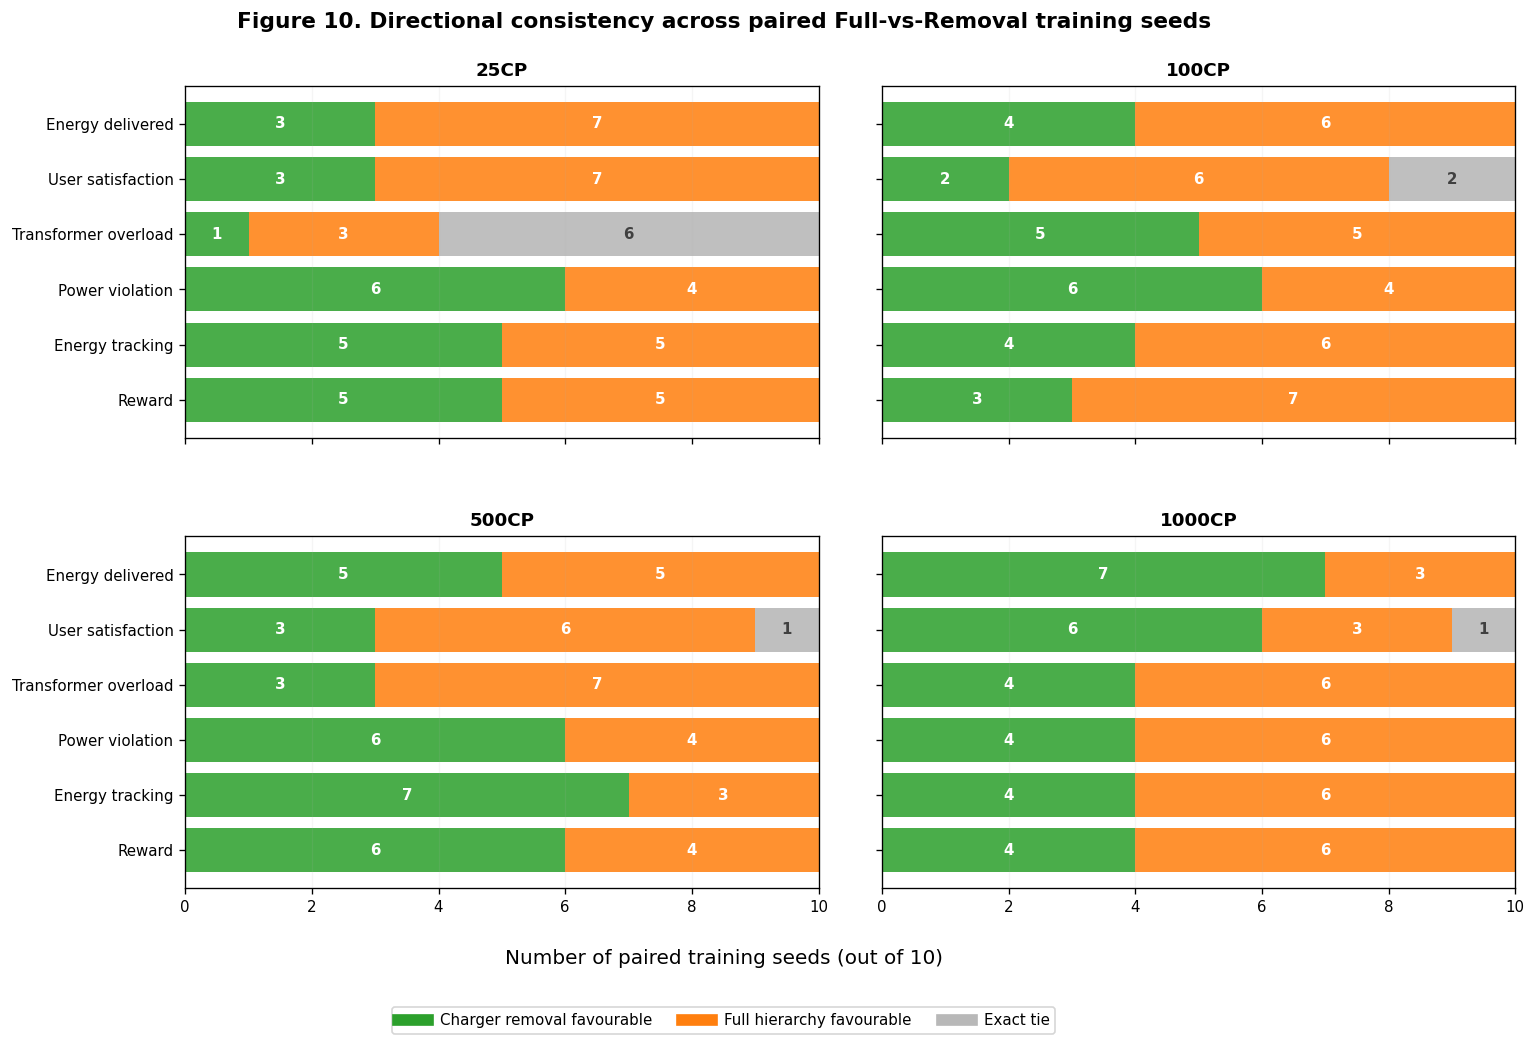

In [20]:
direction_metrics = [
    ("Reward", "episode_reward", 1.0),
    ("Energy tracking", "energy_tracking_error", -1.0),
    ("Power violation", "power_tracker_violation", -1.0),
    ("Transformer overload", "transformer_overload", -1.0),
    ("User satisfaction", "average_satisfaction", 1.0),
    ("Energy delivered", "energy_delivered", 1.0),
]

fig, axes = plt.subplots(2, 2, figsize=(13.6, 8.8), sharex=True, sharey=True)
fig.subplots_adjust(left=0.17, right=0.985, bottom=0.15, top=0.91, hspace=0.28, wspace=0.10)

for panel, (ax, scale) in enumerate(zip(axes.ravel(), SCALE_ORDER)):
    labels = [label for label, _, _ in direction_metrics]
    y = np.arange(len(labels))
    removal_counts = []
    full_counts = []
    tie_counts = []

    for _, metric, direction in direction_metrics:
        frame = policy_eval if metric != "transformer_overload" else policy_diag

        full = (
            frame[
                (frame["scale"] == scale)
                & (frame["architecture"] == "full")
            ]
            .set_index("training_seed")[metric]
            .sort_index()
        )
        removal = (
            frame[
                (frame["scale"] == scale)
                & (frame["architecture"] == "removal")
            ]
            .set_index("training_seed")[metric]
            .sort_index()
        )

        favourable = direction * (removal - full)
        removal_counts.append(int((favourable > 0).sum()))
        full_counts.append(int((favourable < 0).sum()))
        tie_counts.append(int((favourable == 0).sum()))

    removal_counts = np.asarray(removal_counts)
    full_counts = np.asarray(full_counts)
    tie_counts = np.asarray(tie_counts)

    ax.barh(
        y,
        removal_counts,
        color=ARCH_COLOUR["removal"],
        alpha=0.86,
    )
    ax.barh(
        y,
        full_counts,
        left=removal_counts,
        color=ARCH_COLOUR["full"],
        alpha=0.86,
    )
    if tie_counts.any():
        ax.barh(
            y,
            tie_counts,
            left=removal_counts + full_counts,
            color="0.72",
            alpha=0.90,
        )

    for yi, rc, fc, tc in zip(y, removal_counts, full_counts, tie_counts):
        if rc:
            ax.text(
                rc / 2, yi, str(rc),
                ha="center", va="center",
                color="white", fontsize=9, fontweight="semibold",
            )
        if fc:
            ax.text(
                rc + fc / 2, yi, str(fc),
                ha="center", va="center",
                color="white", fontsize=9, fontweight="semibold",
            )
        if tc:
            ax.text(
                rc + fc + tc / 2, yi, str(tc),
                ha="center", va="center",
                color="0.25", fontsize=9, fontweight="semibold",
            )

    ax.set_xlim(0, 10)
    ax.set_xticks(range(0, 11, 2))
    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.12)

    if panel % 2 == 0:
        ax.set_yticks(y, labels)
    else:
        ax.tick_params(labelleft=False)

fig.supxlabel("Number of paired training seeds (out of 10)", y=0.075)
fig.legend(
    handles=[
        Line2D([0], [0], color=ARCH_COLOUR["removal"], lw=7,
               label="Charger removal favourable"),
        Line2D([0], [0], color=ARCH_COLOUR["full"], lw=7,
               label="Full hierarchy favourable"),
        Line2D([0], [0], color="0.72", lw=7,
               label="Exact tie"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.005),
    ncol=3,
    frameon=True,
)
fig.suptitle(
    "Figure 10. Directional consistency across paired Full-vs-Removal training seeds",
    fontsize=13,
    fontweight="bold",
)
plt.show()

### Reading Figure 10

Figure 10 is deliberately a **direction-count** figure. It does not show effect size and it does not convert a seed count into a deployment probability.

Its purpose is to distinguish results such as:

- a large mean effect produced by one extreme seed;
- a smaller mean effect that is repeated in most training pairs.

That distinction is especially important for 500CP and 1000CP, where the reward mean is strongly tail-sensitive.

# Cross-scale architecture attribution

The evidence now supports a more specific research statement than the original Baseline-vs-Full comparison.

### 25CP

The original full hierarchy improves reward relative to the Baseline, and charger removal preserves almost the same mean reward. The graded-action mechanism also remains strongly present. This is evidence that the charger stage is not necessary for the main lower-scale behavioural benefit.

### 100CP

Both hierarchical variants retain much better mean reward than the Baseline, but the exact Full-vs-Removal seed ordering is mixed. Again, the graded-action mechanism survives charger removal.

### 500CP

The charger-removed mean reward is much better than the Full-Hierarchy mean, but this is primarily a **failure-tail rescue** rather than a uniform typical-seed improvement. Removal also produces much lower positive-action concentration at transformer and charger-group levels, although those concentration changes should not be interpreted as the cause of the reward result.

### 1000CP

The direction reverses. Charger removal introduces a severe reduced-hierarchy tail failure and larger across-seed reward dispersion. This is consistent with a possible stabilising role for the charger stage in the largest configuration, but that interpretation is not a statistically resolved universal effect.

## H1 / H2 / H3 adjudication

### H1 — Charger-level allocation is broadly necessary

**Not supported as a general claim.**  
The principal graded-action mechanism survives removal, and the lower-scale control benefit is largely retained.

### H2 — Charger-level allocation is broadly over-constraining

**Not supported as a universal claim.**  
The 500CP result gives partial evidence that the extra factorisation can introduce a harmful optimisation tail, but 1000CP shows the opposite pattern.

### H3 — Transformer-level hierarchy is the principal contributor

**Strongly supported for the action-space mechanism.**  
Transformer-level hierarchical decision formation is sufficient to reproduce the major shift from boundary-dominated charging toward graded continuous EV actions.

For overall reward, overload, and service, the conclusion remains **configuration-dependent** rather than universal.

# Practical interpretation

### Charging point operator

The hierarchical family changes how the controller distributes charging commands, not only the final aggregate reward. Transformer-level hierarchy alone is enough to produce the major shift toward graded EV actions.

### Infrastructure operator

A more graded action distribution does not automatically reduce transformer overload. Infrastructure stress remains unresolved and must be measured separately from tracking reward.

### EV users

Service outcomes are heterogeneous and partly affected by the same rare training failures that influence reward at 500CP and 1000CP. No architecture can be declared universally superior for user service from these results.

### Architecture design

The ablation narrows the architectural contribution:

> The charger level is **not required** for the principal graded-control mechanism, but it can still change optimisation constraints and failure-tail behaviour in ways that depend on the formal configuration.

# Conclusion

The Formal75K study first established that infrastructure-aligned hierarchical decision formation can materially change TD3 EV-GNN behaviour relative to the direct-action baseline. The strongest recurring mechanism was a large reduction in maximum-boundary charging together with much greater use of interior continuous EV actions.

The charger-level ablation refines that claim.

**Transformer-level hierarchical decision formation is sufficient to retain the principal graded-action mechanism.** Explicit charger-level allocation is therefore not necessary for that behavioural change.

At the same time, the charger stage is not simply redundant. Its removal changes the failure-tail structure in opposite directions at 500CP and 1000CP: the reduced hierarchy avoids a severe Full-Hierarchy failure at 500CP but introduces a severe reduced-hierarchy failure at 1000CP. Across the four formal scenarios, however, no Full-Hierarchy-vs-Charger-Removal mean reward difference is statistically resolved after the four-scale Holm correction.

The resulting architecture claim is therefore narrower and more informative than a simple model ranking:

> **Transformer-level hierarchy explains the principal action-space mechanism, while charger-level factorisation appears to modify optimisation and tail-risk behaviour in a configuration-dependent manner.**

Infrastructure overload and EV-user service remain separate unresolved design dimensions.

# Next controlled research question

The architecture-attribution result should be treated as complete before changing the objective.

The remaining question is now different:

> Can the controller explicitly account for infrastructure stress and EV-user service without destroying the tracking and graded-control behaviour already established?

That motivates a later controlled reward/objective-design experiment. No penalty design is introduced in the present notebook.

# Appendix A — Metric glossary

| Metric | Meaning | Preferred direction |
|---|---|---|
| Episode reward | Primary PublicPST control outcome; equal to negative tracking error in the final-evaluation tables | Higher / less negative |
| Tracking error | Aggregate mismatch between requested and realised power | Lower |
| Energy-tracking error | Energy-domain tracking mismatch | Lower |
| Power-tracker violation | Magnitude/frequency aggregate used for setpoint violation | Lower |
| Zero active-EV action fraction | Share of active-EV decisions receiving zero charging command | Context dependent |
| Interior active-EV action fraction | Positive active-EV action below the upper boundary | Mechanism metric, not inherently better |
| Maximum active-EV action fraction | Share of active-EV decisions at the upper action boundary | Lower means less boundary concentration, not automatically better control |
| Transformer overload | Diagnostic transformer-overload aggregate | Lower |
| Transformer HHI | Concentration of positive charging action across transformer groups | Descriptive |
| Charger-group HHI | Concentration of positive charging action across charger groups | Descriptive |
| Gini | Inequality of positive charging-action distribution | Descriptive |
| Average satisfaction | Mean EV-user satisfaction | Higher |
| Energy delivered | Total charging energy delivered | Higher only when interpreted with tracking/service context |
| EVs served | Number of EVs served | Higher only when interpreted with configuration context |

# Appendix B — Complete paired reward statistics

The main text emphasises the pre-specified mean effect, confidence interval, seed direction, and Holm-adjusted paired \(t\)-test. The supplementary table below retains the complementary Wilcoxon, exact sign-flip, and paired effect-size results for all three architecture contrasts.

In [21]:
def full_reward_table(frame, effect_name):
    rows = []
    for _, r in frame.iterrows():
        rows.append({
            "Contrast": effect_name,
            "Scenario": SCALE_LABELS[r["scale"]],
            "Mean effect": signed_compact(r["mean_difference"]),
            "95% CI": (
                f"[{signed_compact(r['ci95_low'])}, "
                f"{signed_compact(r['ci95_high'])}]"
            ),
            "Median": signed_compact(r["median_difference"]),
            "Cohen dz": f"{r['cohen_dz']:.2f}",
            "Positive pairs": f"{int(r['positive_pairs'])}/10",
            "Paired t p": f"{r['paired_t_p']:.4f}",
            "Wilcoxon p": f"{r['wilcoxon_p']:.4f}",
            "Exact sign-flip p": f"{r['sign_flip_p']:.4f}",
            "Holm p": f"{r['holm_p']:.4f}",
        })
    return pd.DataFrame(rows)

supplementary_reward = pd.concat([
    full_reward_table(
        full_vs_baseline_reward,
        "Full Hierarchy − Baseline",
    ),
    full_reward_table(
        removal_vs_full_reward,
        "Charger Removed − Full Hierarchy",
    ),
    full_reward_table(
        removal_vs_baseline_reward,
        "Charger Removed − Baseline",
    ),
], ignore_index=True)

display(supplementary_reward)

,Contrast,Scenario,Mean effect,95% CI,Median,Cohen dz,Positive pairs,Paired t p,Wilcoxon p,Exact sign-flip p,Holm p
0,Full Hierarchy − Baseline,25CP,+19.18k,"[+7.19k, +31.16k]",+18.38k,1.14,9/10,0.0056,0.0039,0.0039,0.0223
1,Full Hierarchy − Baseline,100CP,+1.62M,"[-39.28k, +3.29M]",+316.03k,0.70,9/10,0.0546,0.0098,0.0098,0.1637
2,Full Hierarchy − Baseline,500CP,+13.31M,"[-37.55M, +64.17M]",+343.54,0.19,6/10,0.5684,0.4316,0.3320,0.5826
3,Full Hierarchy − Baseline,1000CP,+61.61M,"[-62.72M, +185.95M]",+1.48M,0.35,7/10,0.2913,0.0840,0.1328,0.5826
4,Charger Removed − Full Hierarchy,25CP,+636.78,"[-10.35k, +11.62k]",+302.95,0.04,5/10,0.8986,0.7695,0.8945,1.0000
5,Charger Removed − Full Hierarchy,100CP,+35.33k,"[-106.68k, +177.35k]",-382.89,0.18,3/10,0.5873,0.8457,0.5938,1.0000
6,Charger Removed − Full Hierarchy,500CP,+12.33M,"[-14.77M, +39.44M]",+10.77k,0.33,6/10,0.3303,0.4316,0.2715,0.9908
7,Charger Removed − Full Hierarchy,1000CP,-62.70M,"[-176.20M, +50.79M]",-5.32M,-0.40,4/10,0.2429,0.1309,0.0625,0.9716
8,Charger Removed − Baseline,25CP,+19.81k,"[+10.77k, +28.85k]",+21.71k,1.57,9/10,0.0008,0.0039,0.0039,0.0031
9,Charger Removed − Baseline,100CP,+1.66M,"[-85.65k, +3.40M]",+262.32k,0.68,6/10,0.0599,0.0840,0.0312,0.1798


# Appendix C — Seed-level checkpoint map

The selected-checkpoint medians in Figure 3 are useful summaries, but the seed map below shows whether those medians come from a narrow cluster or from very different selection times across independent runs.

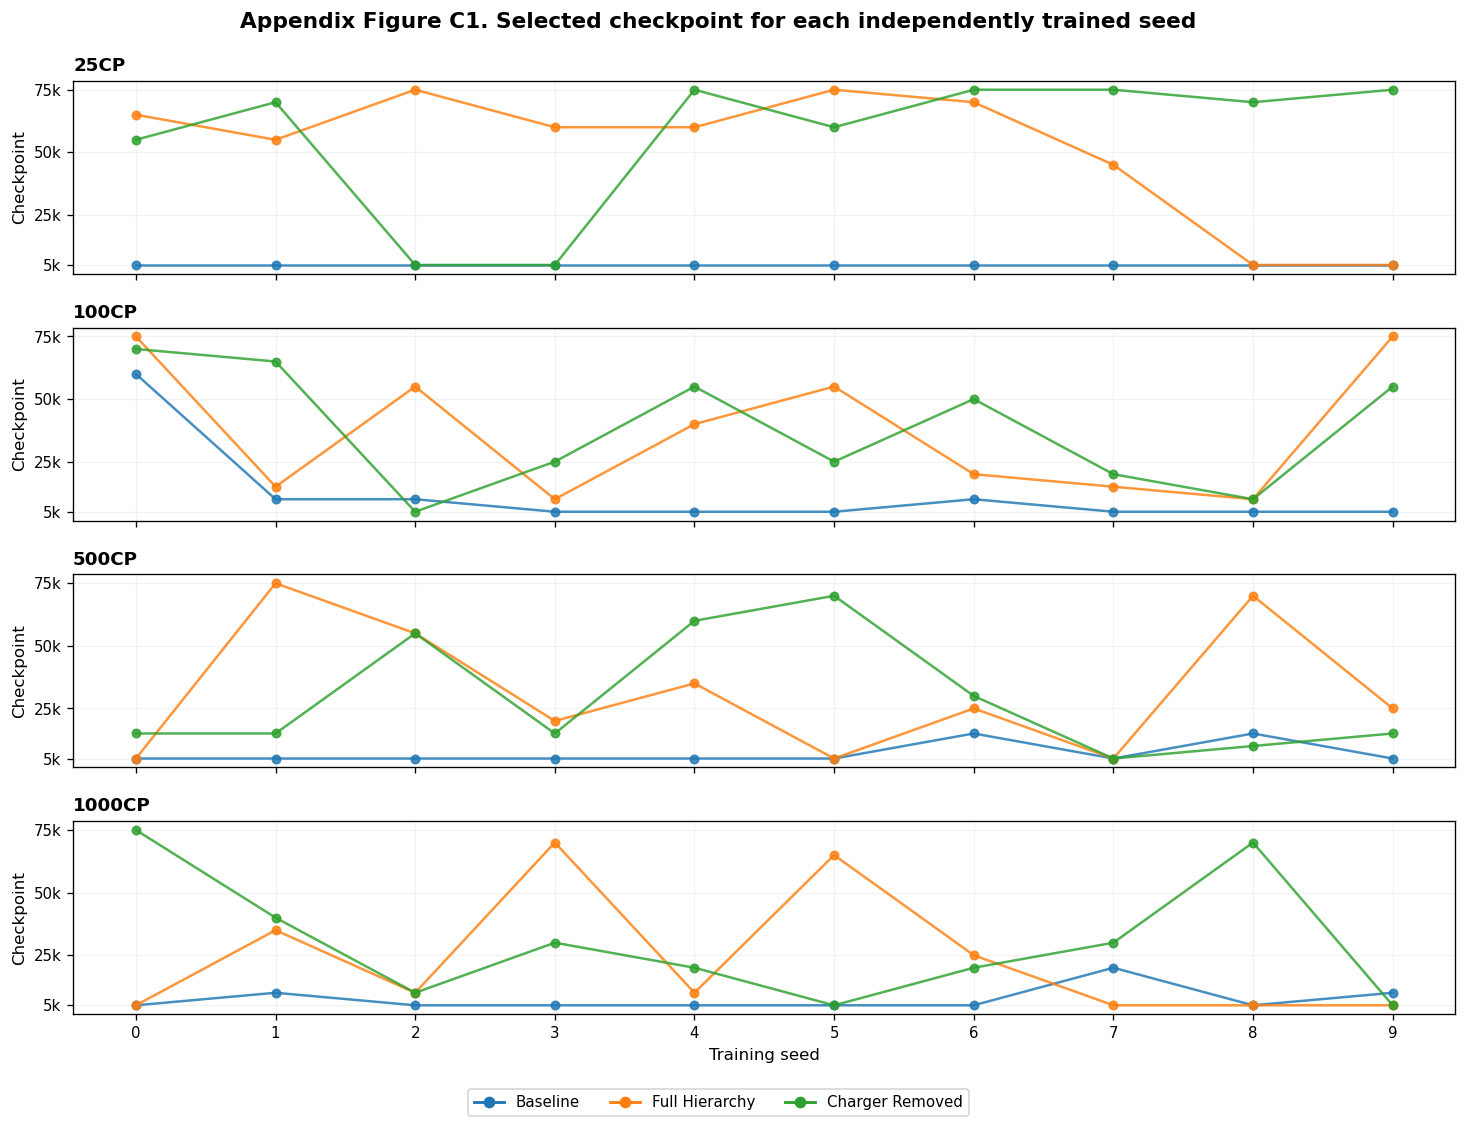

In [22]:
fig, axes = plt.subplots(4, 1, figsize=(12.8, 9.6), sharex=True)
fig.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.11, hspace=0.28)

for ax, scale in zip(axes, SCALE_ORDER):
    d = checkpoint_frame[checkpoint_frame["scale"] == scale]

    for architecture in ARCH_ORDER:
        a = d[d["architecture"] == architecture].sort_values("training_seed")
        ax.plot(
            a["training_seed"],
            a["selected_checkpoint_step"],
            marker="o",
            linewidth=1.5,
            markersize=5,
            color=ARCH_COLOUR[architecture],
            alpha=0.82,
            label=ARCH_SHORT[architecture],
        )

    ax.set_title(SCALE_LABELS[scale], loc="left", fontweight="semibold")
    ax.set_ylabel("Checkpoint")
    ax.set_yticks([5000, 25000, 50000, 75000])
    ax.set_yticklabels(["5k", "25k", "50k", "75k"])
    ax.grid(alpha=0.14)

axes[-1].set_xlabel("Training seed")
axes[-1].set_xticks(range(10))

fig.legend(
    handles=[
        Line2D([0], [0], marker="o", color=ARCH_COLOUR[a], lw=1.7,
               label=ARCH_SHORT[a])
        for a in ARCH_ORDER
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=3,
    frameon=True,
)
fig.suptitle(
    "Appendix Figure C1. Selected checkpoint for each independently trained seed",
    fontsize=13,
    fontweight="bold",
)
plt.show()

# Appendix D — Allocation inequality beyond HHI

HHI emphasises concentration of positive charging action into a small number of groups. Gini provides a complementary inequality view.

The figure below keeps transformer and charger-group Gini descriptive. It is included to show how the allocation pattern changes, not to rank the architectures by a single "better/worse" concentration score.

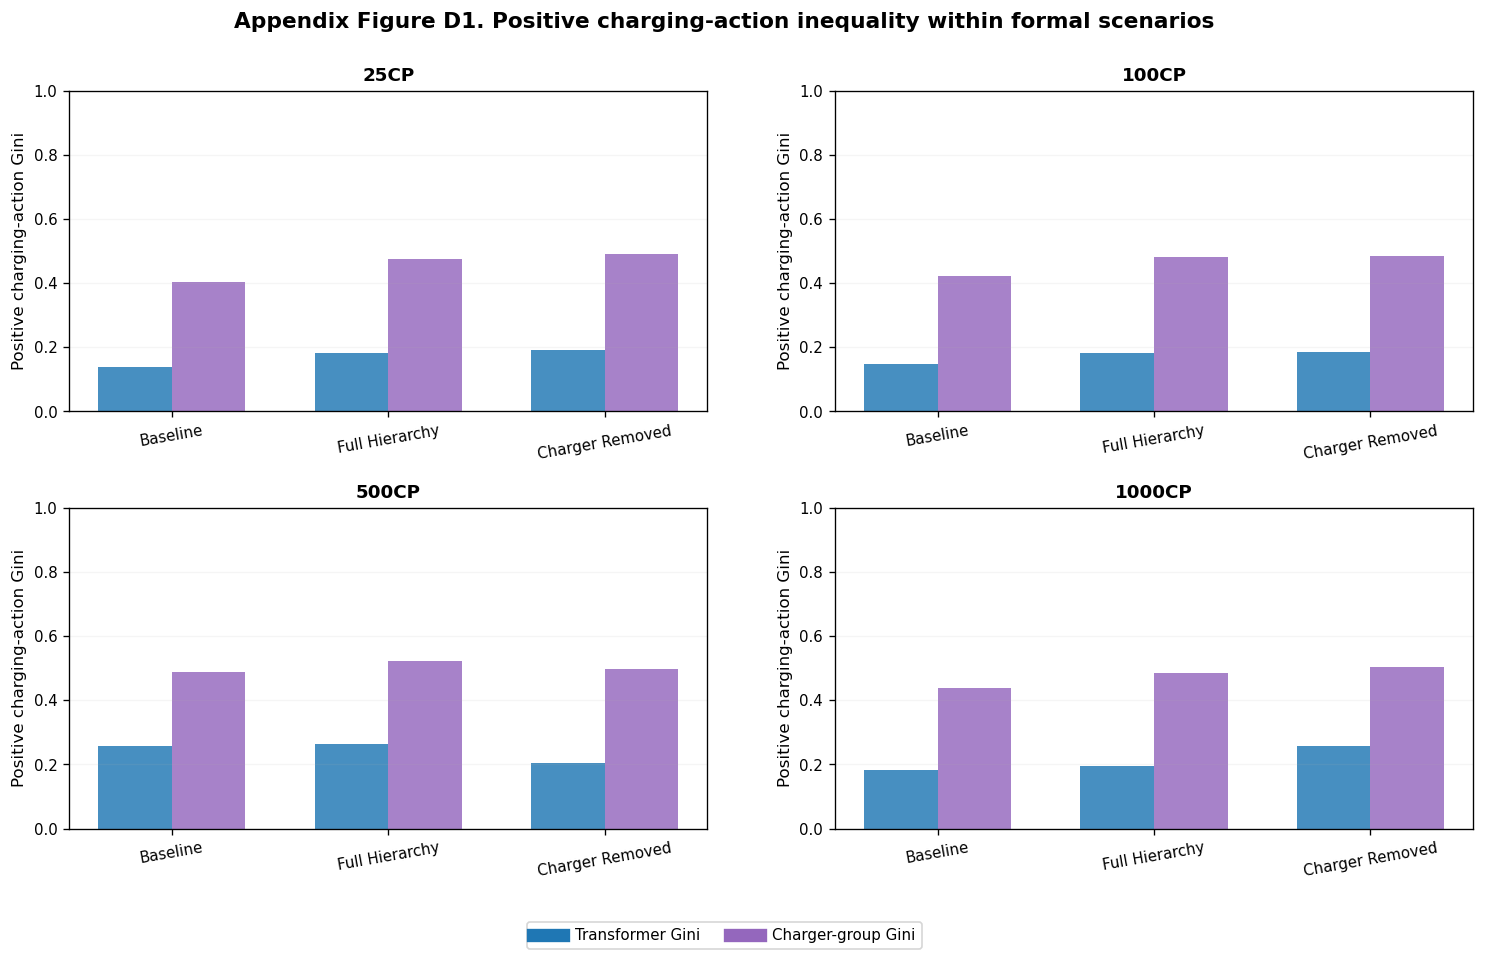

In [23]:
gini_summary = (
    policy_diag
    .groupby(["scale", "architecture"], observed=True)[
        ["transformer_gini", "charger_group_gini"]
    ]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(13.0, 8.2))
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.15, hspace=0.30, wspace=0.20)

width = 0.34
for ax, scale in zip(axes.ravel(), SCALE_ORDER):
    d = (
        gini_summary[gini_summary["scale"] == scale]
        .set_index("architecture")
        .loc[ARCH_ORDER]
    )
    x = np.arange(len(ARCH_ORDER))

    ax.bar(
        x - width / 2,
        d["transformer_gini"],
        width=width,
        color=_cycle[0],
        alpha=0.82,
        label="Transformer Gini",
    )
    ax.bar(
        x + width / 2,
        d["charger_group_gini"],
        width=width,
        color=_cycle[4],
        alpha=0.82,
        label="Charger-group Gini",
    )

    ax.set_xticks(x, [ARCH_SHORT[a] for a in ARCH_ORDER], rotation=10)
    ax.set_title(SCALE_LABELS[scale], fontweight="semibold")
    ax.set_ylabel("Positive charging-action Gini")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.12)

fig.legend(
    handles=[
        Line2D([0], [0], color=_cycle[0], lw=8, label="Transformer Gini"),
        Line2D([0], [0], color=_cycle[4], lw=8, label="Charger-group Gini"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=True,
)
fig.suptitle(
    "Appendix Figure D1. Positive charging-action inequality within formal scenarios",
    fontsize=13,
    fontweight="bold",
)
plt.show()

## Allocation-distribution interpretation

The HHI/Gini evidence reinforces the same bounded conclusion as the main infrastructure section: the charger-removal intervention can materially change how positive charging action is distributed across the physical hierarchy, but the direction is not uniform across formal configurations.

Those concentration measures are therefore best treated as **mechanism evidence**. Their relationship with reward and transformer overload is descriptive rather than a separately identified causal effect.